In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [3]:
from pathlib import Path


# ==========================================================
# CONFIGURACIÓN
# ==========================================================
INPUT_FILE = Path("S3_bga_003600_neutrons.shw")
OUTPUT_FILE = Path("S3_bga_003600_neutrons_MeV.dat")

# Conversión de GeV/c a MeV/c
GEV_TO_MEV = 1000.0

# Código CORSIKA de neutrón
NEUTRON_CODE = "0013"


# ==========================================================
# CONVERSIÓN DEL ARCHIVO
# ==========================================================
def convert_neutron_file(input_file: Path, output_file: Path) -> None:
    """
    Convierte un archivo con columnas:

    particle px py pz x y z shower_id prm_id
    prm_energy prm_theta prm_phi

    a un archivo con formato:

    neutron px(MeV/c) py(MeV/c) pz(MeV/c)
    x y z 0 0 0 0 0
    """

    if not input_file.exists():
        raise FileNotFoundError(
            f"No se encontró el archivo de entrada: {input_file}"
        )

    total_lines = 0
    converted_lines = 0
    skipped_lines = 0

    with input_file.open("r", encoding="utf-8") as source, \
         output_file.open("w", encoding="utf-8") as destination:

        for line_number, raw_line in enumerate(source, start=1):
            line = raw_line.strip()

            # Ignorar líneas vacías
            if not line:
                continue

            # Ignorar comentarios, si existen
            if line.startswith("#"):
                continue

            total_lines += 1
            columns = line.split()

            # Se esperan 12 columnas
            if len(columns) < 12:
                print(
                    f"Advertencia: línea {line_number} ignorada; "
                    f"solo contiene {len(columns)} columnas."
                )
                skipped_lines += 1
                continue

            particle_code = columns[0]

            # El archivo debería contener neutrones 0013
            if particle_code != NEUTRON_CODE:
                print(
                    f"Advertencia: línea {line_number} ignorada; "
                    f"partícula {particle_code} distinta de {NEUTRON_CODE}."
                )
                skipped_lines += 1
                continue

            try:
                # Momento original en GeV/c
                px_gev = float(columns[1])
                py_gev = float(columns[2])
                pz_gev = float(columns[3])

                # Posiciones: se conservan en las unidades originales
                x = float(columns[4])
                y = float(columns[5])
                z = float(columns[6])

            except ValueError:
                print(
                    f"Advertencia: línea {line_number} ignorada por "
                    "contener valores numéricos inválidos."
                )
                skipped_lines += 1
                continue

            # Conversión de GeV/c a MeV/c
            px_mev = px_gev * GEV_TO_MEV
            py_mev = py_gev * GEV_TO_MEV
            pz_mev = pz_gev * GEV_TO_MEV

            # Formato final:
            # neutron px py pz x y z 0 0 0 0 0
            destination.write(
                f"neutron "
                f"{px_mev:.8g} "
                f"{py_mev:.8g} "
                f"{pz_mev:.8g} "
                f"{x:.8g} "
                f"{y:.8g} "
                f"{z:.8g} "
                f"0 0 0 0 0\n"
            )

            converted_lines += 1

    print("\nConversión finalizada.")
    print(f"Líneas procesadas: {total_lines}")
    print(f"Neutrones convertidos: {converted_lines}")
    print(f"Líneas ignoradas: {skipped_lines}")
    print(f"Archivo generado: {output_file.resolve()}")


# ==========================================================
# EJECUCIÓN
# ==========================================================
if __name__ == "__main__":
    try:
        convert_neutron_file(INPUT_FILE, OUTPUT_FILE)
    except Exception as error:
        print(f"Error durante la conversión: {error}")


Conversión finalizada.
Líneas procesadas: 317537
Neutrones convertidos: 317537
Líneas ignoradas: 0
Archivo generado: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Flujo-completo-Bga/Flujo-Arti-BGA/S3_bga_003600_neutrons_MeV.dat


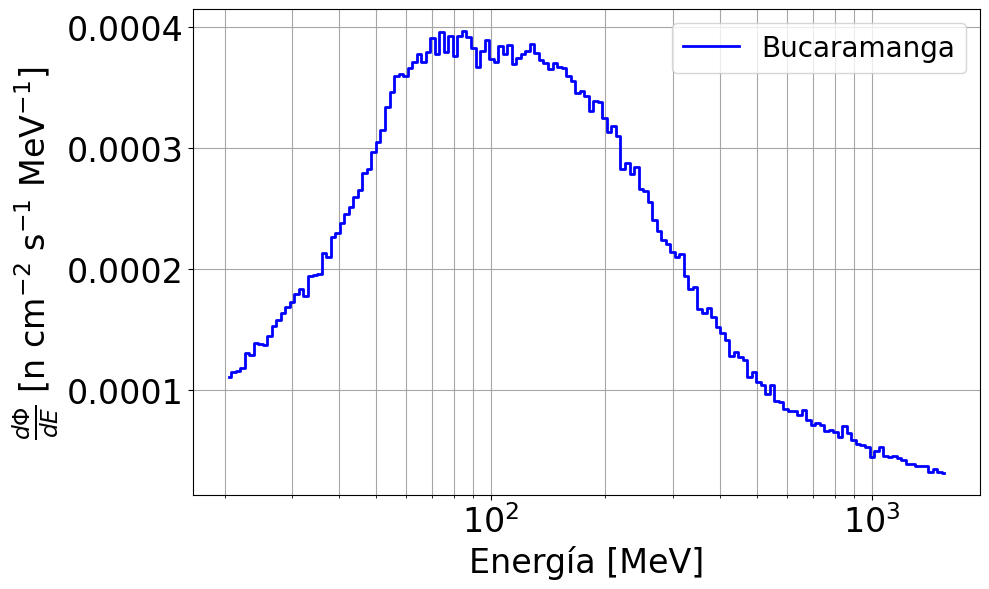

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir área de detección (cm²) y tiempos de integración (s)
A = (40000)**2  # Área en cm²
time_default = 12 * 3600 / (400**2)  # Tiempo por defecto en segundos
time_mcg = (1/4) * 3600 / (400**2)  # Tiempo específico para (1 hora en segundos, ajusta según necesites)

# Lista de archivos de entrada y sus tiempos correspondientes
#input_file1 = "all_neutron_yny_SAN11.shw"
input_file2 = "S3_bga_003600_neutrons_MeV.shw"
files = [input_file2]
times = [time_mcg]  # Lista de tiempos para cada archivo
labels = ["Bucaramanga"]

# Función para procesar los archivos y graficar solo el flujo letárgico
def neutron_flux(files, times, output_pdf_name, A):
    """
    Procesa múltiples archivos de flujos de neutrones y grafica solo el flujo letárgico.
    
    :param files: Lista de archivos de entrada.
    :param times: Lista de tiempos de integración (s) para cada archivo.
    :param output_pdf_name: Nombre del archivo de salida para la gráfica.
    :param A: Área de detección (cm²).
    """
    m = 939.6  # Masa del neutrón en MeV/c^2
    plt.figure(figsize=(10, 6))  # Crear figura
    colors = ['b', 'r', 'g', 'm', 'c', 'y', 'k']  # Colores para diferenciar curvas
    
    for i, file in enumerate(files):
        # Usar el tiempo correspondiente a este archivo
        time = times[i]
        
        # Leer el archivo CSV con formato adecuado
        df = pd.read_csv(file, delimiter=" ", skiprows=1, skipinitialspace=True, comment="#", on_bad_lines='skip')
        df.columns = ["particle", "px", "py", "pz", "x", "y", "z", "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"]
        
        # Filtrar solo los neutrones
        df_neutrons = df[df["particle"] == "neutron"].copy()
        
        # Calcular la energía cinética (Ek) usando la fórmula Ek = (p² / 2m)
        df_neutrons["Ek"] = (df_neutrons["px"]**2 + df_neutrons["py"]**2 + df_neutrons["pz"]**2) / (2 * m)
        
        # Filtrar energías válidas (Ek < 1573 MeV y Ek != 0)
        df_neutrons = df_neutrons[(df_neutrons["Ek"] < 1573.0) & (df_neutrons["Ek"] != 0)]
        neu_Ek = np.array(df_neutrons["Ek"])
        
        # Definir bins logarítmicos para energía
        min_Ek, max_Ek = np.min(neu_Ek), np.max(neu_Ek)
        num_bins = 159
        bins_Ek = np.logspace(np.log10(min_Ek), np.log10(max_Ek), num_bins + 1)
        
        # Calcular histograma de energía cinética
        y_diff, _ = np.histogram(neu_Ek, bins=bins_Ek, density=False)
        bin_centers = (bins_Ek[1:] + bins_Ek[:-1]) / 2  # Centros de los bins
        bin_widths = bins_Ek[1:] - bins_Ek[:-1]  # Ancho de los bins
        
        # Calcular flujo diferencial
        phi_diff = y_diff / (A * time * bin_centers)
        
        # Calcular flujo letárgico: φ_lethargy(u) = φ_diff(E) * E_mid
        phi_lethargy = phi_diff * bin_centers
        
        # Graficar flujo letárgico
        color = colors[i % len(colors)]  # Ciclar colores si hay más archivos
        plt.step(bin_centers, phi_lethargy, color=color, where='mid', label=f'{labels[i]}', linewidth=2)
    
    # Configuración de la gráfica
    plt.xscale('log')  # Escala logarítmica en el eje X
    plt.xlabel('Energía [MeV]', size=24)
    #plt.ylabel('Thermal flux [n·cm⁻²·s⁻¹]', size=24)
    #plt.ylabel('Flujo [n·cm⁻²·s⁻¹MeV⁻¹]', size=24)
    plt.ylabel(r'$\frac{d\Phi}{dE}$ [n cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]',fontsize=24)
    plt.title('', size=20)
    plt.grid(True, which="both", ls="-", color='0.65')
    plt.legend()
    plt.legend(fontsize=20)
    plt.tick_params(labelsize=24)
    
    # Guardar la gráfica en un archivo
    plt.tight_layout()
    plt.savefig(output_pdf_name)
    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig('Flujo_diferencia_neutrones_rapidos.png', format='png')
    plt.savefig('Flujo_diferencia_neutrones_rapidos.pdf', format='pdf')
    plt.show()

# Ejecutar la función con los archivos y tiempos especificados
output_name = "Completo_flux_neutrons.png"
neutron_flux(files, times, output_name, A)


In [2]:
Masa_neutron=0.939565
# Especifica el nombre del archivo
nombre_archivo = 'S3_bga_003600_neutrons.shw'

# Inicializa un diccionario con nombres de columnas predeterminados
nombres_columnas = {
    0: 'CorsikaId',
    1: 'px',
    2: 'py',
    3: 'pz',
    4: 'x',
    5: 'y',
    6: 'z',
    7: 'shower_id',
    8: 'prm_id',
    9: 'prm_energy',
    10: 'prm_theta',
    11: 'prm_phi'
}

# Lee el archivo con pandas
# El separador es un espacio en blanco, y saltamos las líneas que comienzan con '#'
#datos = pd.read_csv(nombre_archivo, delim_whitespace=True, comment='#', header=None)
datos = pd.read_csv(nombre_archivo, sep=r"\s+", comment="#", header=None)
# Asigna los nombres de las columnas
datos.columns = [nombres_columnas[col] for col in datos.columns]
datos['momento'] = ((datos['px']**2 + datos['py']**2 + datos['pz']**2)**0.5)
momento_particulas = datos['log_momento'] = np.log(datos['momento'])
# Encuentra el valor mínimo de momento para neutrones
min_momentum = datos_neutrones['momento'].min()
# Cortar un poco más a la izquierda del valor mínimo (factor de seguridad)
xmin = min_momentum * 0.9  # o 0.5 si quieres un margen mayor

print(datos.head())
plt.figure(figsize=(14, 8))
nombre_archivo_salida = 'Flujo_total_particulas.txt'
datos.to_csv(nombre_archivo_salida, sep='\t', index=False)
print(f'Datos guardados en {nombre_archivo_salida}:\n', datos.head())




datos_neutrones = datos[datos['CorsikaId'] == 13]
nombre_archivo_neutrones = 'Flujo_total_neutrones.txt'
datos_neutrones.to_csv(nombre_archivo_neutrones, sep='\t', index=False)
print(f'Datos guardados en {nombre_archivo_neutrones}:\n', datos_neutrones.head())

#datos_seleccionados['momento'] = ((datos_seleccionados['px']**2 + datos_seleccionados['py']**2 + datos_seleccionados['pz']**2)**0.5)*1000
momento_neutron_log = datos_neutrones['log_momento'] = np.log(datos_neutrones['momento'])

#momento_neutron_log = np.log(datos_neutrones['momento'])
momento_filtrado = momento_neutron_log[momento_neutron_log >= np.log(min_momentum)]

num_entries = len(momento_neutron_log)
mean = sum(momento_neutron_log) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in momento_neutron_log) / num_entries)
info_text = f'Neutrones\nEntradas:{num_entries}\nMedio: {mean:.2f}\nD. est.: {std_dev:.2f}'
#plt.text(1.01, 0.90, info_text, fontsize=9, transform=plt.gca().transAxes, bbox=dict(facecolor='brown', alpha=0.5))
# Visualizar el resultado
#plt.hist(momento_neutron_log, bins=50,histtype='step', lw=1.5,edgecolor='brown')
plt.hist(momento_filtrado, bins=50, histtype='step', lw=1.5, edgecolor='brown')
# Dibujar línea vertical en el mínimo real
#plt.axvline(x=min_momentum, color='red', linestyle='--', linewidth=2, label=f'Mínimo: {min_momentum:.2e} GeV/c')

plt.title('')
#plt.xlabel('Log(p(MeV))', fontsize=20)
plt.xlabel('Momemtum [GeV/c]', fontsize=20)
plt.xscale('log')
plt.xlim(0.01, 10)
#plt.xlim(0.0001, 10)
#plt.xlim(xmin, 10) 
plt.ylabel('[$Particles.m^{-2}.s^{-1}$]', fontsize=20)
plt.yscale('log')
plt.grid(True)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
pdf_filename_stat_charge = 'Flujo-Arti-30sg.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Flujo-Arti-neutrones.jpg', format='jpg')
plt.show()




TypeError: read_csv() got an unexpected keyword argument 'delim_whitespace'

Datos totales guardados en Flujo_total_particulas.txt
   CorsikaId        px        py        pz         x         y        z  \
0         13 -0.110037 -0.171260  0.341909  -1646.36  -4673.84  954.073   
1         13 -0.209549  0.087710  0.271046  -7084.27  -3355.29  951.179   
2         13 -0.100925 -0.150680  0.511796  -6436.08  -8502.45  947.077   
3         13  0.003620  0.147451  0.411867   8375.27 -12954.40  937.328   
4         13  0.294855 -0.198937  0.300837  39511.10 -32472.60  750.764   

   shower_id  prm_id  prm_energy  prm_theta  prm_phi   momento  log_momento  
0          1     703    108.2030     16.046  137.980  0.397919    -0.921506  
1          3     703     45.8431     32.107   79.752  0.353652    -1.039442  
2          4     703     18.0225     39.114   -9.108  0.542978    -0.610686  
3          7     703     49.4401     39.324  157.070  0.437481    -0.826723  
4          8     703     54.4295     56.993  130.887  0.465852    -0.763887  
Datos de neutrones guardado

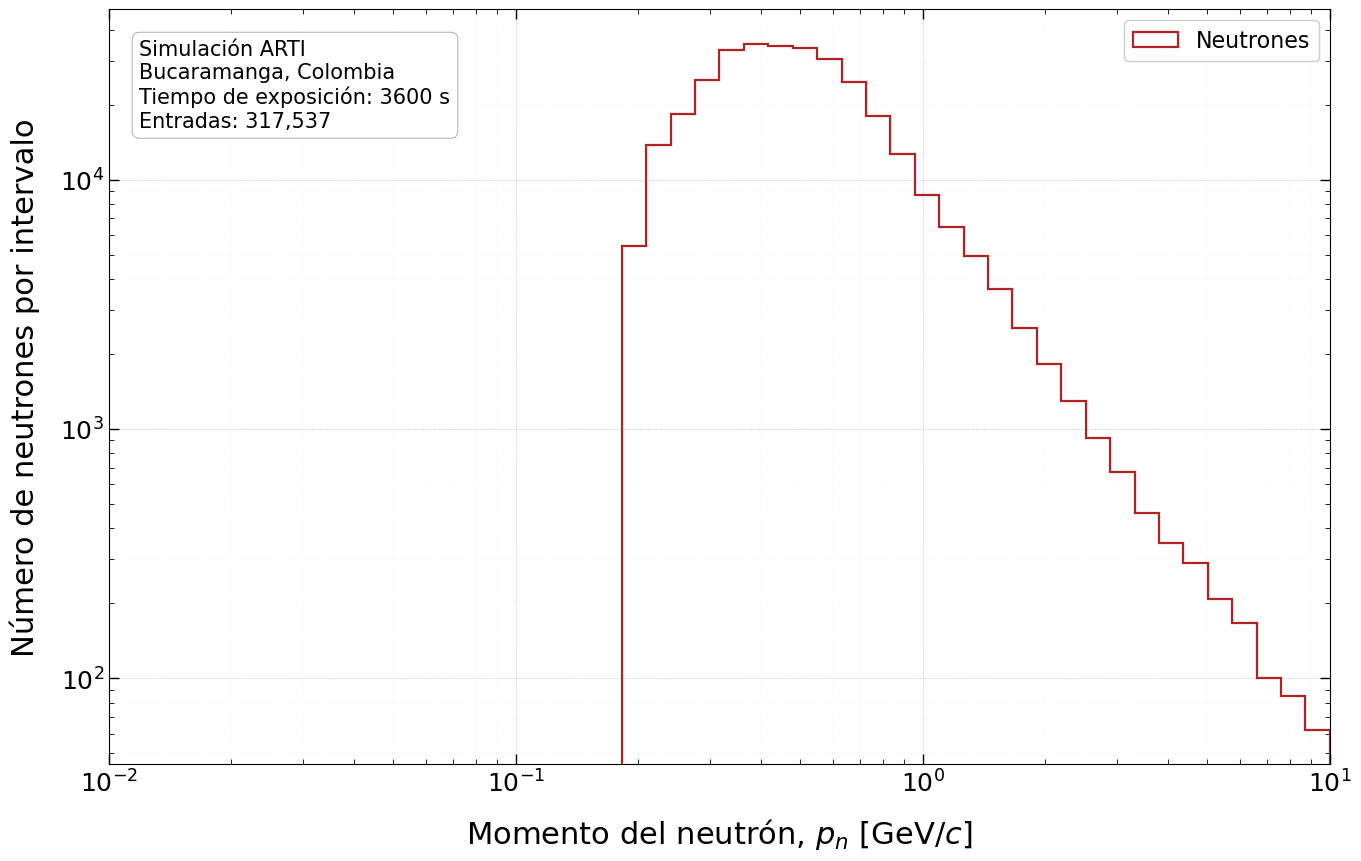

Figura generada correctamente.
PDF: Flujo-Arti-30sg.pdf
PNG: Flujo-Arti-neutrones.png


In [4]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

MASA_NEUTRON = 0.939565  # GeV/c^2

NOMBRE_ARCHIVO = "S3_bga_003600_neutrons.shw"

ARCHIVO_DATOS_TOTALES = "Flujo_total_particulas.txt"
ARCHIVO_DATOS_NEUTRONES = "Flujo_total_neutrones.txt"

ARCHIVO_PDF = "Flujo-Arti-30sg.pdf"
ARCHIVO_PNG = "Flujo-Arti-neutrones.png"


# ==========================================================
# NOMBRES DE LAS COLUMNAS
# ==========================================================

nombres_columnas = {
    0: "CorsikaId",
    1: "px",
    2: "py",
    3: "pz",
    4: "x",
    5: "y",
    6: "z",
    7: "shower_id",
    8: "prm_id",
    9: "prm_energy",
    10: "prm_theta",
    11: "prm_phi"
}


# ==========================================================
# COMPROBAR QUE EL ARCHIVO EXISTE
# ==========================================================

if not os.path.exists(NOMBRE_ARCHIVO):
    raise FileNotFoundError(
        f"No se encontró el archivo: {NOMBRE_ARCHIVO}"
    )


# ==========================================================
# LEER EL ARCHIVO
# ==========================================================

datos = pd.read_csv(
    NOMBRE_ARCHIVO,

    # Uno o más espacios o tabulaciones
    sep=r"\s+",

    # Ignorar líneas que comienzan con #
    comment="#",

    # El archivo no contiene encabezado
    header=None
)


# ==========================================================
# COMPROBAR EL NÚMERO DE COLUMNAS
# ==========================================================

numero_columnas = datos.shape[1]

if numero_columnas != len(nombres_columnas):
    raise ValueError(
        f"El archivo contiene {numero_columnas} columnas, "
        f"pero se esperaban {len(nombres_columnas)}."
    )


# Asignar nombres
datos.columns = [
    nombres_columnas[indice]
    for indice in datos.columns
]


# ==========================================================
# CONVERTIR COLUMNAS NUMÉRICAS
# ==========================================================

columnas_numericas = [
    "CorsikaId",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]

for columna in columnas_numericas:

    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )


# Eliminar filas que no tengan valores válidos en las
# componentes del momento
datos = datos.dropna(
    subset=[
        "CorsikaId",
        "px",
        "py",
        "pz"
    ]
).copy()


# ==========================================================
# CALCULAR EL MÓDULO DEL MOMENTO
# ==========================================================

datos["momento"] = np.sqrt(
    datos["px"] ** 2
    + datos["py"] ** 2
    + datos["pz"] ** 2
)


# Eliminar momentos nulos o negativos, porque no pueden
# representarse en escala logarítmica
datos = datos[
    datos["momento"] > 0
].copy()


# Si necesitas guardar también el logaritmo natural:
datos["log_momento"] = np.log(
    datos["momento"]
)


# ==========================================================
# GUARDAR TODAS LAS PARTÍCULAS
# ==========================================================

datos.to_csv(
    ARCHIVO_DATOS_TOTALES,
    sep="\t",
    index=False
)

print(
    f"Datos totales guardados en "
    f"{ARCHIVO_DATOS_TOTALES}"
)

print(datos.head())


# ==========================================================
# SELECCIONAR LOS NEUTRONES
# ==========================================================

# En la convención usada en tu archivo CORSIKA:
# CorsikaId = 13 corresponde a neutrones.
datos_neutrones = datos[
    datos["CorsikaId"] == 13
].copy()


if datos_neutrones.empty:
    raise ValueError(
        "No se encontraron partículas con CorsikaId = 13."
    )


datos_neutrones.to_csv(
    ARCHIVO_DATOS_NEUTRONES,
    sep="\t",
    index=False
)

print(
    f"Datos de neutrones guardados en "
    f"{ARCHIVO_DATOS_NEUTRONES}"
)

print(datos_neutrones.head())


# ==========================================================
# MOMENTO DE LOS NEUTRONES
# ==========================================================

momento_neutrones = datos_neutrones[
    "momento"
].to_numpy()


min_momentum = np.min(
    momento_neutrones
)

max_momentum = np.max(
    momento_neutrones
)

xmin = min_momentum * 0.9

print(
    f"Momento mínimo: {min_momentum:.6e} GeV/c"
)

print(
    f"Momento máximo: {max_momentum:.6e} GeV/c"
)


# ==========================================================
# ESTADÍSTICAS
# ==========================================================

num_entries = len(
    momento_neutrones
)

mean = np.mean(
    momento_neutrones
)

std_dev = np.std(
    momento_neutrones,
    ddof=0
)

print(f"Entradas: {num_entries}")
print(f"Momento medio: {mean:.6e} GeV/c")
print(f"Desviación estándar: {std_dev:.6e} GeV/c")


# ==========================================================
# BINS LOGARÍTMICOS
# ==========================================================

X_MIN = 1.0e-2
X_MAX = 1.0e1
NUM_BINS = 50

bordes = np.logspace(
    np.log10(X_MIN),
    np.log10(X_MAX),
    NUM_BINS + 1
)


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(13.5, 8.5),
    constrained_layout=True
)


# ==========================================================
# HISTOGRAMA
# ==========================================================

ax.hist(
    momento_neutrones,
    bins=bordes,
    histtype="step",
    linewidth=1.6,
    color="firebrick",
    label="Neutrones",
    zorder=5
)


# ==========================================================
# ESCALAS Y LÍMITES
# ==========================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    X_MIN,
    X_MAX
)


# ==========================================================
# ETIQUETAS
# ==========================================================

ax.set_xlabel(
    r"Momento del neutrón, $p_n$ [GeV/$c$]",
    fontsize=22,
    labelpad=14
)

ax.set_ylabel(
    "Número de neutrones por intervalo",
    fontsize=22,
    labelpad=14
)


# ==========================================================
# TICKS
# ==========================================================

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=18,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.6,
    top=True,
    right=True
)


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.55,
    color="0.55",
    alpha=0.35
)

ax.grid(
    visible=True,
    which="minor",
    axis="both",
    linestyle=":",
    linewidth=0.32,
    color="0.65",
    alpha=0.13
)

ax.set_axisbelow(True)


# ==========================================================
# INFORMACIÓN DE LA SIMULACIÓN
# ==========================================================

texto_informacion = (
    "Simulación ARTI\n"
    "Bucaramanga, Colombia\n"
    "Tiempo de exposición: 3600 s\n"
    f"Entradas: {num_entries:,}"
)

ax.text(
    0.025,
    0.96,
    texto_informacion,
    transform=ax.transAxes,
    fontsize=15,
    ha="left",
    va="top",
    bbox=dict(
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        boxstyle="round,pad=0.35",
        alpha=0.92
    ),
    zorder=10
)


# ==========================================================
# LEYENDA
# ==========================================================

ax.legend(
    loc="upper right",
    fontsize=16,
    frameon=True,
    framealpha=0.94
)


# ==========================================================
# GUARDAR
# ==========================================================

fig.savefig(
    ARCHIVO_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

fig.savefig(
    ARCHIVO_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)


# ==========================================================
# MOSTRAR Y CERRAR
# ==========================================================

plt.show()
plt.close(fig)

print("Figura generada correctamente.")
print(f"PDF: {ARCHIVO_PDF}")
print(f"PNG: {ARCHIVO_PNG}")


Resumen de la simulación
------------------------
Archivo: S3_bga_003600_neutrons.shw
Neutrones totales: 317,537
Neutrones graficados: 317,369
Tiempo: 30.00 s
Área efectiva: 1.0000 m²
Momento mínimo: 1.948958e-01 GeV/c
Momento máximo: 1.362834e+02 GeV/c
Energía cinética mínima: 2.000092e-02 GeV
Energía cinética máxima: 1.353471e+02 GeV


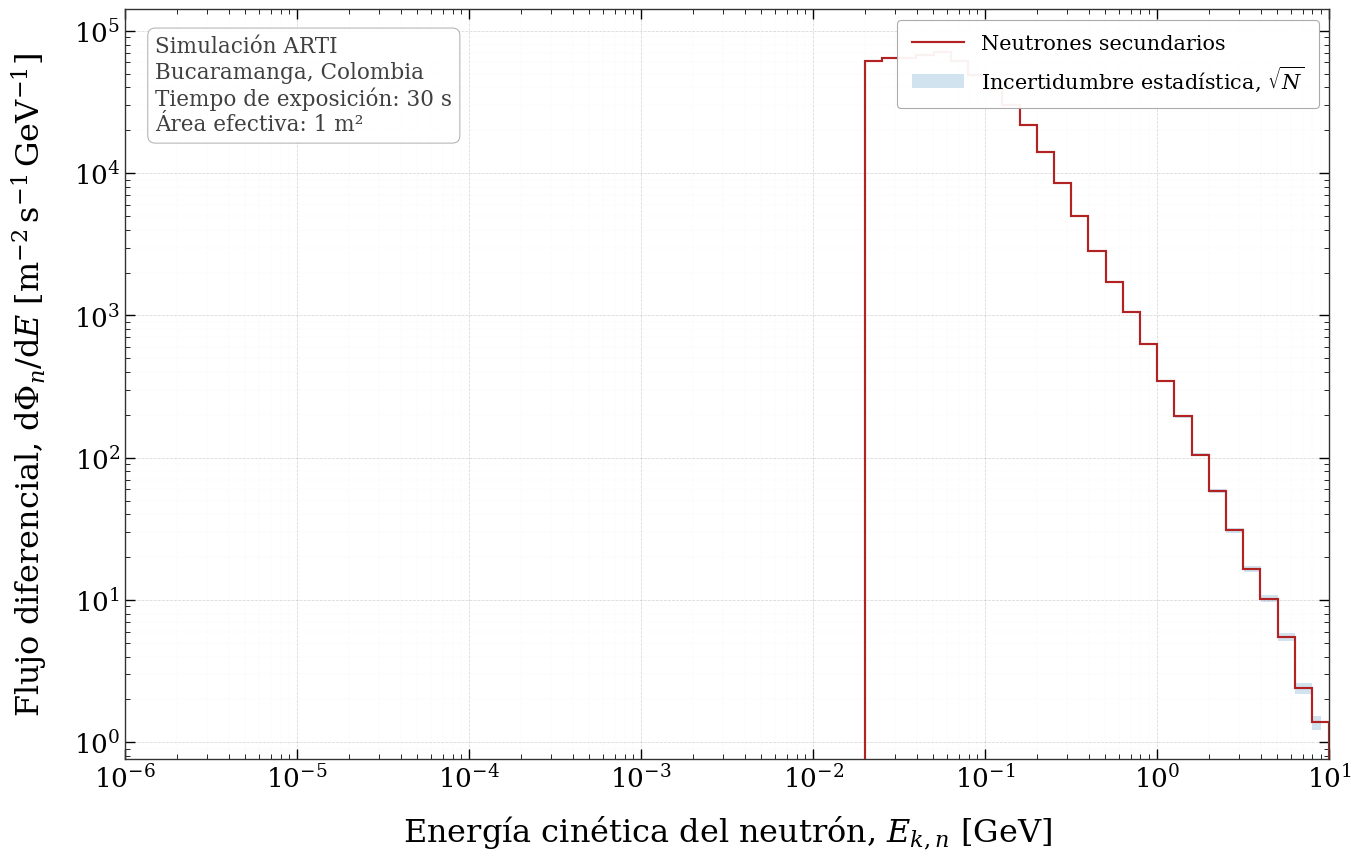


Figura generada correctamente.
Datos: Flujo-neutrones-energia-ARTI/Flujo_neutrones_en_funcion_energia.txt
PDF:   Flujo-neutrones-energia-ARTI/Flujo-neutrones-energia-ARTI.pdf
PNG:   Flujo-neutrones-energia-ARTI/Flujo-neutrones-energia-ARTI.png


Diferencia máxima entre los dos métodos: 1.455192e-11 MeV

Resumen del espectro
--------------------
Archivo de entrada: S3_bga_003600_neutrons.shw
Neutrones encontrados: 317,537
Neutrones dentro del intervalo: 317,369
Momento mínimo: 1.948958e+02 MeV/c
Momento máximo: 1.362834e+05 MeV/c
Energía cinética mínima total: 2.000092e+01 MeV
Energía cinética máxima total: 1.353471e+05 MeV
Tiempo de exposición: 30.00 s
Área efectiva: 1.000000 m²
Número de bins: 80


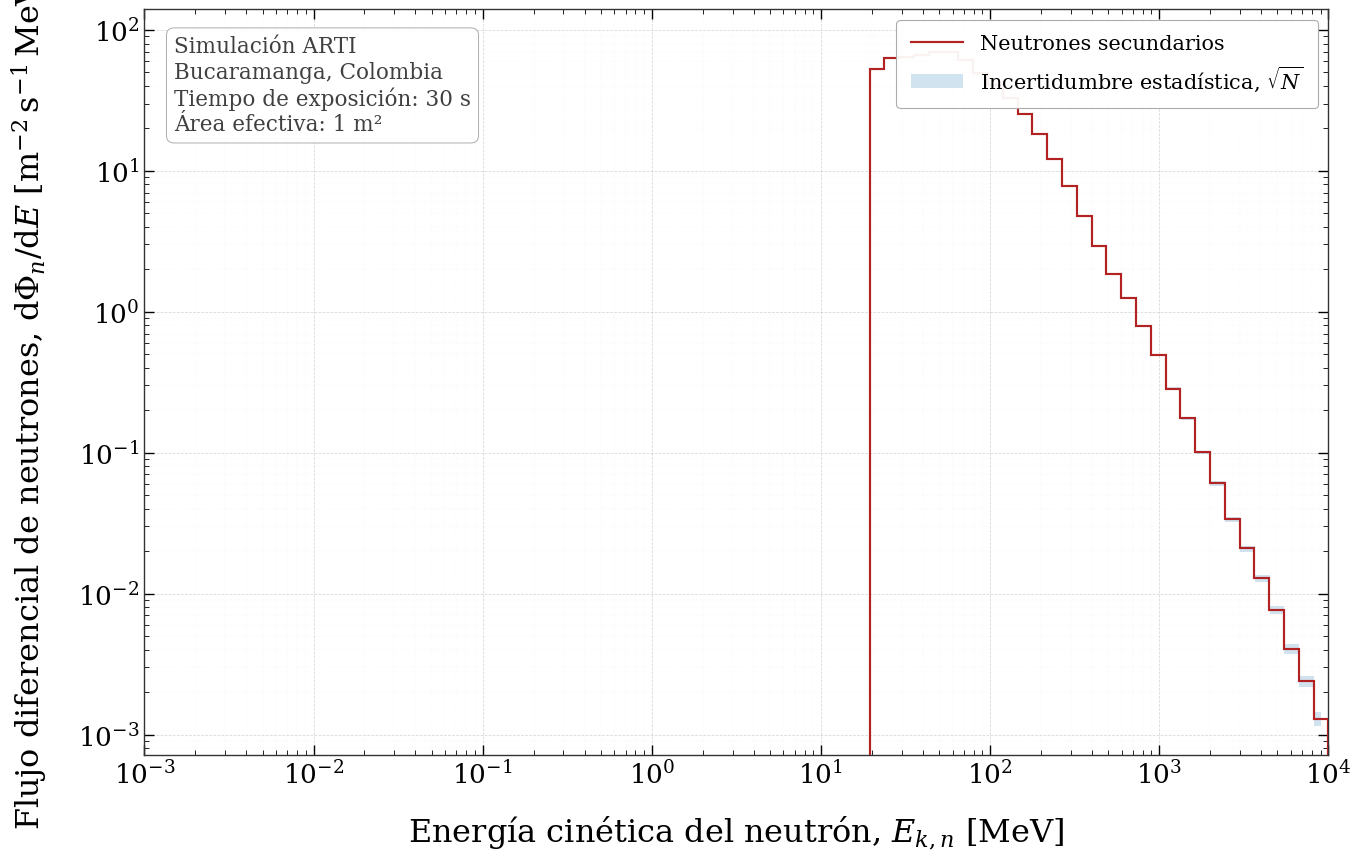


Archivos generados correctamente.
Neutrones: Flujo-neutrones-energia-MeV-ARTI/Neutrones_con_energia_cinetica_MeV.txt
Espectro:  Flujo-neutrones-energia-MeV-ARTI/Flujo_neutrones_en_funcion_energia_MeV.txt
PDF:       Flujo-neutrones-energia-MeV-ARTI/Flujo-neutrones-energia-MeV-ARTI.pdf
PNG:       Flujo-neutrones-energia-MeV-ARTI/Flujo-neutrones-energia-MeV-ARTI.png


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

ARCHIVO_ENTRADA = "S3_bga_003600_neutrons.shw"

OUTDIR = "Flujo-neutrones-energia-MeV-ARTI"
os.makedirs(OUTDIR, exist_ok=True)

ARCHIVO_NEUTRONES = os.path.join(
    OUTDIR,
    "Neutrones_con_energia_cinetica_MeV.txt"
)

ARCHIVO_ESPECTRO = os.path.join(
    OUTDIR,
    "Flujo_neutrones_en_funcion_energia_MeV.txt"
)

ARCHIVO_PDF = os.path.join(
    OUTDIR,
    "Flujo-neutrones-energia-MeV-ARTI.pdf"
)

ARCHIVO_PNG = os.path.join(
    OUTDIR,
    "Flujo-neutrones-energia-MeV-ARTI.png"
)


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

# Masa en reposo del neutrón:
# m_n c² = 939.565 MeV
MASA_NEUTRON_MEV = 939.565

# Conversión de GeV a MeV
GEV_A_MEV = 1000.0

# Identificador del neutrón en el archivo CORSIKA/ARTI
CORSIKA_ID_NEUTRON = 13


# ==========================================================
# PARÁMETROS DE NORMALIZACIÓN
# ==========================================================

# Tiempo de exposición de la simulación
TIEMPO_EXPOSICION_S = 30.0

# Área efectiva de muestreo.
#
# IMPORTANTE:
# reemplaza 1.0 por el área real utilizada en ARTI.
AREA_EFECTIVA_M2 = 1.0


# ==========================================================
# INTERVALO ENERGÉTICO
# ==========================================================

# Límites del espectro en MeV.
#
# Para neutrones atmosféricos puedes modificar estos valores
# según el intervalo realmente contenido en el archivo.
ENERGIA_MIN_MEV = 1.0e-3
ENERGIA_MAX_MEV = 1.0e4

# Número de bins logarítmicos
NUM_BINS = 80


# ==========================================================
# NOMBRES DE LAS COLUMNAS DEL ARCHIVO
# ==========================================================

NOMBRES_COLUMNAS = [
    "CorsikaId",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 23,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,

    "axes.linewidth": 1.0,

    # Mantener fuentes editables en PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# COMPROBAR ARCHIVO DE ENTRADA
# ==========================================================

if not os.path.exists(ARCHIVO_ENTRADA):
    raise FileNotFoundError(
        f"No se encontró el archivo: {ARCHIVO_ENTRADA}"
    )


# ==========================================================
# LEER EL ARCHIVO ARTI/CORSIKA
# ==========================================================

datos = pd.read_csv(
    ARCHIVO_ENTRADA,
    sep=r"\s+",
    comment="#",
    header=None
)

numero_columnas = datos.shape[1]

if numero_columnas != len(NOMBRES_COLUMNAS):
    raise ValueError(
        f"El archivo contiene {numero_columnas} columnas, "
        f"pero se esperaban {len(NOMBRES_COLUMNAS)}."
    )

datos.columns = NOMBRES_COLUMNAS


# ==========================================================
# CONVERTIR COLUMNAS A FORMATO NUMÉRICO
# ==========================================================

for columna in NOMBRES_COLUMNAS:

    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

# Eliminar filas sin información válida
datos = datos.dropna(
    subset=[
        "CorsikaId",
        "px",
        "py",
        "pz"
    ]
).copy()


# ==========================================================
# SELECCIONAR NEUTRONES
# ==========================================================

datos_neutrones = datos[
    datos["CorsikaId"] == CORSIKA_ID_NEUTRON
].copy()

if datos_neutrones.empty:
    raise ValueError(
        f"No se encontraron partículas con "
        f"CorsikaId = {CORSIKA_ID_NEUTRON}."
    )


# ==========================================================
# CALCULAR EL MOMENTO TOTAL
# ==========================================================
#
# Se supone que px, py y pz están en GeV/c.
# ==========================================================

datos_neutrones["momento_GeV_c"] = np.sqrt(
    datos_neutrones["px"]**2
    + datos_neutrones["py"]**2
    + datos_neutrones["pz"]**2
)

# Eliminar valores no físicos
datos_neutrones = datos_neutrones[
    np.isfinite(datos_neutrones["momento_GeV_c"])
    & (datos_neutrones["momento_GeV_c"] > 0)
].copy()


# ==========================================================
# CONVERTIR MOMENTO DE GeV/c A MeV/c
# ==========================================================

datos_neutrones["momento_MeV_c"] = (
    datos_neutrones["momento_GeV_c"]
    * GEV_A_MEV
)


# ==========================================================
# CALCULAR ENERGÍA TOTAL Y ENERGÍA CINÉTICA EN MeV
# ==========================================================
#
# E_total = sqrt(p² + m²)
#
# E_cinética = E_total - m
#
# p debe estar en MeV/c
# m c² debe estar en MeV
# ==========================================================

momento_MeV_c = datos_neutrones[
    "momento_MeV_c"
].to_numpy()

energia_total_MeV = np.sqrt(
    momento_MeV_c**2
    + MASA_NEUTRON_MEV**2
)

energia_cinetica_MeV = (
    energia_total_MeV
    - MASA_NEUTRON_MEV
)

datos_neutrones["energia_total_MeV"] = (
    energia_total_MeV
)

datos_neutrones["energia_cinetica_MeV"] = (
    energia_cinetica_MeV
)


# ==========================================================
# COMPROBACIÓN OPCIONAL
# ==========================================================
#
# También puede calcularse primero en GeV y después multiplicar
# por 1000:
#
# E_k(MeV) = 1000 * [sqrt(p_GeV² + m_GeV²) - m_GeV]
#
# Ambas formas deben proporcionar el mismo resultado.
# ==========================================================

MASA_NEUTRON_GEV = MASA_NEUTRON_MEV / GEV_A_MEV

energia_cinetica_comprobacion_MeV = GEV_A_MEV * (
    np.sqrt(
        datos_neutrones["momento_GeV_c"].to_numpy()**2
        + MASA_NEUTRON_GEV**2
    )
    - MASA_NEUTRON_GEV
)

diferencia_maxima = np.max(
    np.abs(
        energia_cinetica_MeV
        - energia_cinetica_comprobacion_MeV
    )
)

print(
    "Diferencia máxima entre los dos métodos: "
    f"{diferencia_maxima:.6e} MeV"
)


# ==========================================================
# GUARDAR LOS NEUTRONES CON MOMENTO Y ENERGÍA
# ==========================================================

datos_neutrones.to_csv(
    ARCHIVO_NEUTRONES,
    sep="\t",
    index=False
)


# ==========================================================
# FILTRAR EL INTERVALO ENERGÉTICO
# ==========================================================

mascara_energia = (
    np.isfinite(energia_cinetica_MeV)
    & (energia_cinetica_MeV >= ENERGIA_MIN_MEV)
    & (energia_cinetica_MeV <= ENERGIA_MAX_MEV)
)

energia_filtrada_MeV = energia_cinetica_MeV[
    mascara_energia
]

if energia_filtrada_MeV.size == 0:
    raise ValueError(
        "No quedaron neutrones dentro del intervalo energético. "
        "Revisa ENERGIA_MIN_MEV y ENERGIA_MAX_MEV."
    )


# ==========================================================
# CREAR BINS LOGARÍTMICOS EN MeV
# ==========================================================

bordes_energia_MeV = np.logspace(
    np.log10(ENERGIA_MIN_MEV),
    np.log10(ENERGIA_MAX_MEV),
    NUM_BINS + 1
)

# Para bins logarítmicos, el centro geométrico es más adecuado
centros_energia_MeV = np.sqrt(
    bordes_energia_MeV[:-1]
    * bordes_energia_MeV[1:]
)

anchos_energia_MeV = np.diff(
    bordes_energia_MeV
)


# ==========================================================
# CALCULAR EL HISTOGRAMA
# ==========================================================

conteos, _ = np.histogram(
    energia_filtrada_MeV,
    bins=bordes_energia_MeV
)


# ==========================================================
# NORMALIZACIÓN POR ÁREA Y TIEMPO
# ==========================================================

factor_area_tiempo = (
    AREA_EFECTIVA_M2
    * TIEMPO_EXPOSICION_S
)

if factor_area_tiempo <= 0:
    raise ValueError(
        "El producto AREA_EFECTIVA_M2 × "
        "TIEMPO_EXPOSICION_S debe ser positivo."
    )


# ==========================================================
# FLUJO INTEGRADO POR BIN
# ==========================================================
#
# Phi_i = N_i / (A T)
#
# Unidades:
# m^-2 s^-1
# ==========================================================

flujo_por_bin = (
    conteos
    / factor_area_tiempo
)


# ==========================================================
# FLUJO DIFERENCIAL EN MeV
# ==========================================================
#
# dPhi/dE = N_i / (A T DeltaE_i)
#
# Como DeltaE está en MeV:
#
# unidades:
# m^-2 s^-1 MeV^-1
# ==========================================================

flujo_diferencial_MeV = (
    conteos
    / (
        factor_area_tiempo
        * anchos_energia_MeV
    )
)


# ==========================================================
# INCERTIDUMBRE ESTADÍSTICA DE POISSON
# ==========================================================
#
# sigma_N = sqrt(N)
#
# sigma_dPhi/dE =
# sqrt(N) / (A T DeltaE)
# ==========================================================

incertidumbre_conteos = np.sqrt(
    conteos.astype(float)
)

incertidumbre_flujo_MeV = (
    incertidumbre_conteos
    / (
        factor_area_tiempo
        * anchos_energia_MeV
    )
)


# ==========================================================
# PREPARAR VALORES PARA ESCALA LOGARÍTMICA
# ==========================================================

flujo_visible = np.where(
    flujo_diferencial_MeV > 0,
    flujo_diferencial_MeV,
    np.nan
)

limite_inferior = np.where(
    flujo_diferencial_MeV
    - incertidumbre_flujo_MeV
    > 0,
    flujo_diferencial_MeV
    - incertidumbre_flujo_MeV,
    np.nan
)

limite_superior = np.where(
    flujo_diferencial_MeV > 0,
    flujo_diferencial_MeV
    + incertidumbre_flujo_MeV,
    np.nan
)


# ==========================================================
# GUARDAR EL ESPECTRO
# ==========================================================

resultados = np.column_stack([
    bordes_energia_MeV[:-1],
    bordes_energia_MeV[1:],
    centros_energia_MeV,
    anchos_energia_MeV,
    conteos,
    flujo_por_bin,
    flujo_diferencial_MeV,
    incertidumbre_flujo_MeV
])

encabezado = (
    "E_min_MeV "
    "E_max_MeV "
    "E_centro_MeV "
    "DeltaE_MeV "
    "Conteos "
    "Flujo_por_bin_m-2_s-1 "
    "Flujo_diferencial_m-2_s-1_MeV-1 "
    "Incertidumbre_m-2_s-1_MeV-1"
)

np.savetxt(
    ARCHIVO_ESPECTRO,
    resultados,
    header=encabezado,
    fmt=[
        "%.8e",
        "%.8e",
        "%.8e",
        "%.8e",
        "%d",
        "%.8e",
        "%.8e",
        "%.8e"
    ]
)


# ==========================================================
# MOSTRAR INFORMACIÓN EN TERMINAL
# ==========================================================

print("\nResumen del espectro")
print("--------------------")

print(
    f"Archivo de entrada: {ARCHIVO_ENTRADA}"
)

print(
    f"Neutrones encontrados: "
    f"{len(datos_neutrones):,}"
)

print(
    f"Neutrones dentro del intervalo: "
    f"{len(energia_filtrada_MeV):,}"
)

print(
    f"Momento mínimo: "
    f"{np.min(momento_MeV_c):.6e} MeV/c"
)

print(
    f"Momento máximo: "
    f"{np.max(momento_MeV_c):.6e} MeV/c"
)

print(
    f"Energía cinética mínima total: "
    f"{np.min(energia_cinetica_MeV):.6e} MeV"
)

print(
    f"Energía cinética máxima total: "
    f"{np.max(energia_cinetica_MeV):.6e} MeV"
)

print(
    f"Tiempo de exposición: "
    f"{TIEMPO_EXPOSICION_S:.2f} s"
)

print(
    f"Área efectiva: "
    f"{AREA_EFECTIVA_M2:.6f} m²"
)

print(
    f"Número de bins: {NUM_BINS}"
)


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(13.5, 8.5),
    constrained_layout=True
)


# ==========================================================
# GRAFICAR EL FLUJO DIFERENCIAL
# ==========================================================

ax.stairs(
    flujo_diferencial_MeV,
    bordes_energia_MeV,
    linewidth=1.55,
    color="firebrick",
    label="Neutrones secundarios",
    zorder=5
)


# ==========================================================
# BANDA DE INCERTIDUMBRE
# ==========================================================

ax.fill_between(
    centros_energia_MeV,
    limite_inferior,
    limite_superior,
    step="mid",
    alpha=0.20,
    linewidth=0,
    label=r"Incertidumbre estadística, $\sqrt{N}$",
    zorder=3
)


# ==========================================================
# ESCALAS Y LÍMITES
# ==========================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    ENERGIA_MIN_MEV,
    ENERGIA_MAX_MEV
)

valores_positivos = flujo_diferencial_MeV[
    flujo_diferencial_MeV > 0
]

if valores_positivos.size > 0:

    ax.set_ylim(
        np.min(valores_positivos) * 0.55,
        np.max(valores_positivos) * 2.0
    )


# ==========================================================
# ETIQUETAS DE LOS EJES
# ==========================================================

ax.set_xlabel(
    r"Energía cinética del neutrón, $E_{k,n}$ [MeV]",
    labelpad=18
)

ax.set_ylabel(
    r"Flujo diferencial de neutrones, "
    r"$\mathrm{d}\Phi_n/\mathrm{d}E$ "
    r"[$\mathrm{m}^{-2}\,\mathrm{s}^{-1}\,\mathrm{MeV}^{-1}$]",
    labelpad=20
)


# ==========================================================
# CONFIGURACIÓN DE LOS TICKS DEL EJE X
# ==========================================================

ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=12
    )
)

ax.xaxis.set_minor_locator(
    ticker.LogLocator(
        base=10,
        subs=np.arange(2, 10) * 0.1,
        numticks=100
    )
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterMathtext(
        base=10
    )
)

ax.xaxis.set_minor_formatter(
    ticker.NullFormatter()
)


# ==========================================================
# CONFIGURACIÓN DE LOS TICKS DEL EJE Y
# ==========================================================

ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=12
    )
)

ax.yaxis.set_minor_locator(
    ticker.LogLocator(
        base=10,
        subs=np.arange(2, 10) * 0.1,
        numticks=100
    )
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterMathtext(
        base=10
    )
)

ax.yaxis.set_minor_formatter(
    ticker.NullFormatter()
)


# ==========================================================
# APARIENCIA DE LOS TICKS
# ==========================================================

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=19,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.6,
    top=True,
    right=True
)


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.55,
    color="0.55",
    alpha=0.35
)

ax.grid(
    visible=True,
    which="minor",
    axis="both",
    linestyle=":",
    linewidth=0.32,
    color="0.65",
    alpha=0.13
)

ax.set_axisbelow(True)


# ==========================================================
# INFORMACIÓN DE LA SIMULACIÓN
# ==========================================================

texto_simulacion = (
    "Simulación ARTI\n"
    "Bucaramanga, Colombia\n"
    f"Tiempo de exposición: {TIEMPO_EXPOSICION_S:g} s\n"
    f"Área efectiva: {AREA_EFECTIVA_M2:g} m²"
)

ax.text(
    0.025,
    0.965,
    texto_simulacion,
    transform=ax.transAxes,
    fontsize=15.5,
    ha="left",
    va="top",
    color="0.25",
    bbox=dict(
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        boxstyle="round,pad=0.35",
        alpha=0.92
    ),
    zorder=15
)


# ==========================================================
# LEYENDA
# ==========================================================

leyenda = ax.legend(
    loc="upper right",
    fontsize=15,
    frameon=True,
    framealpha=0.94,
    facecolor="white",
    edgecolor="0.65",
    borderpad=0.70,
    labelspacing=0.50,
    handlelength=2.5
)

leyenda.get_frame().set_linewidth(0.8)


# ==========================================================
# ESTILO DE LOS BORDES
# ==========================================================

for spine in ax.spines.values():

    spine.set_linewidth(1.0)
    spine.set_color("0.20")


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.savefig(
    ARCHIVO_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

fig.savefig(
    ARCHIVO_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)


# ==========================================================
# MOSTRAR Y CERRAR
# ==========================================================

plt.show()
plt.close(fig)

print("\nArchivos generados correctamente.")
print(f"Neutrones: {ARCHIVO_NEUTRONES}")
print(f"Espectro:  {ARCHIVO_ESPECTRO}")
print(f"PDF:       {ARCHIVO_PDF}")
print(f"PNG:       {ARCHIVO_PNG}")


Comprobaciones numéricas
-------------------------
Diferencia máxima del módulo del momento: 2.910383045673e-11 MeV/c
Diferencia máxima entre métodos de energía: 1.455191522837e-11 MeV
Residuo relativista máximo: 4.828907549381e-07 MeV²
Archivo detallado: Flujo-neutrones-energia-MeV-ARTI/Verificacion_componentes_momento_y_energia_neutrones.txt
Resumen: Flujo-neutrones-energia-MeV-ARTI/Resumen_verificacion_momento_energia.txt

Primeras filas de la tabla de verificación:
 CorsikaId  shower_id  prm_id  prm_energy  prm_theta  prm_phi  px_GeV_c  py_GeV_c  pz_GeV_c  momento_GeV_c  momento_recalculado_GeV_c   px_MeV_c  py_MeV_c  pz_MeV_c  momento_MeV_c  momento_recalculado_MeV_c  energia_total_MeV  energia_cinetica_MeV  energia_cinetica_comprobacion_MeV  diferencia_momento_GeV_c  diferencia_momento_MeV_c  diferencia_energia_cinetica_MeV  residuo_relativista_MeV2
        13          1     703    108.2030     16.046  137.980 -0.110037 -0.171260  0.341909       0.397919                   0.3979

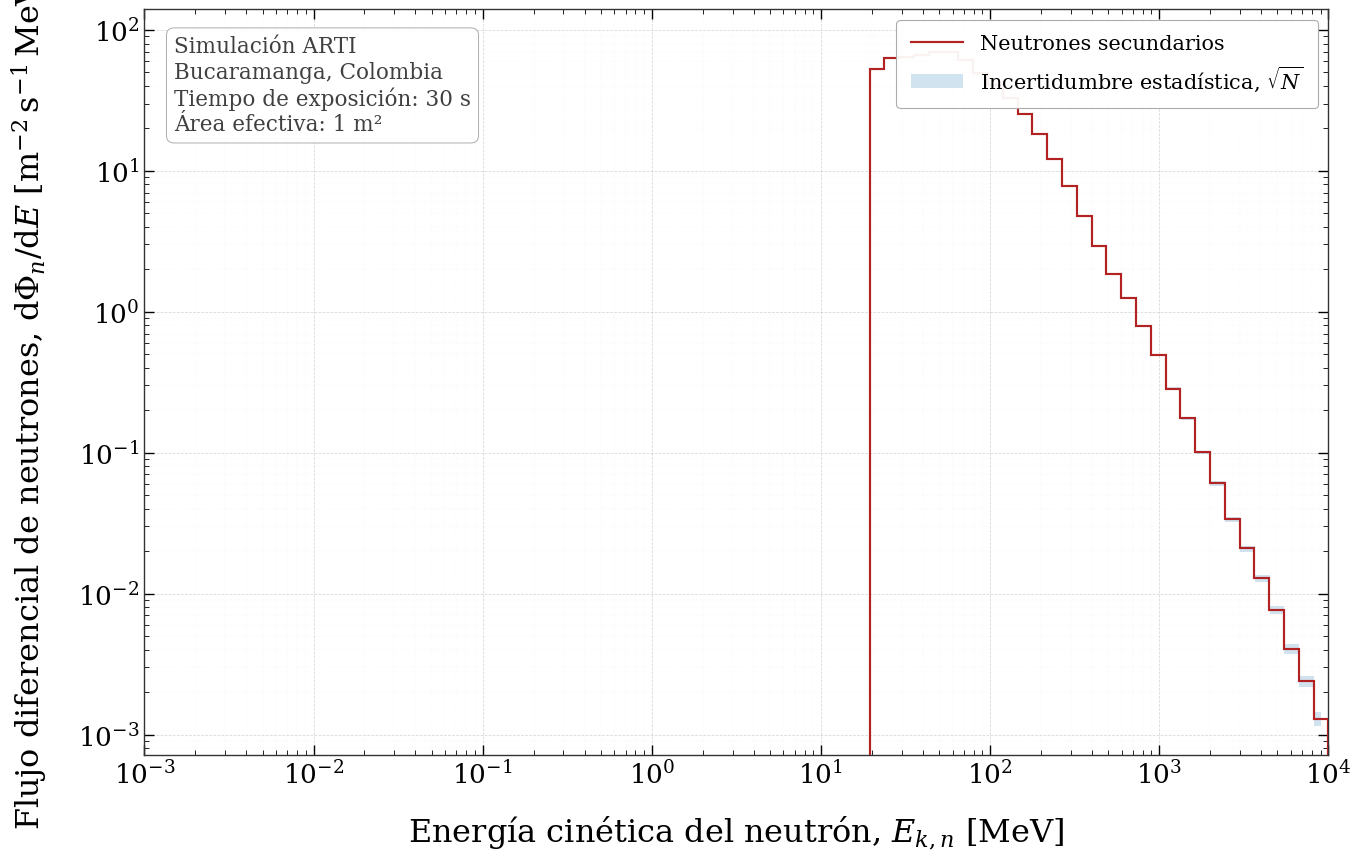


Archivos generados correctamente.
Neutrones:    Flujo-neutrones-energia-MeV-ARTI/Neutrones_con_energia_cinetica_MeV.txt
Verificación: Flujo-neutrones-energia-MeV-ARTI/Verificacion_componentes_momento_y_energia_neutrones.txt
Resumen:      Flujo-neutrones-energia-MeV-ARTI/Resumen_verificacion_momento_energia.txt
Espectro:     Flujo-neutrones-energia-MeV-ARTI/Flujo_neutrones_en_funcion_energia_MeV.txt
PDF:          Flujo-neutrones-energia-MeV-ARTI/Flujo-neutrones-energia-MeV-ARTI.pdf
PNG:          Flujo-neutrones-energia-MeV-ARTI/Flujo-neutrones-energia-MeV-ARTI.png


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

ARCHIVO_ENTRADA = "S3_bga_003600_neutrons.shw"

OUTDIR = "Flujo-neutrones-energia-MeV-ARTI"
os.makedirs(OUTDIR, exist_ok=True)

ARCHIVO_NEUTRONES = os.path.join(
    OUTDIR,
    "Neutrones_con_energia_cinetica_MeV.txt"
)

# Archivo detallado para verificar, neutrón por neutrón,
# las componentes del momento y el cálculo de la energía.
ARCHIVO_VERIFICACION_NEUTRONES = os.path.join(
    OUTDIR,
    "Verificacion_componentes_momento_y_energia_neutrones.txt"
)

# Resumen de las comprobaciones numéricas globales.
ARCHIVO_RESUMEN_VERIFICACION = os.path.join(
    OUTDIR,
    "Resumen_verificacion_momento_energia.txt"
)

ARCHIVO_ESPECTRO = os.path.join(
    OUTDIR,
    "Flujo_neutrones_en_funcion_energia_MeV.txt"
)

ARCHIVO_PDF = os.path.join(
    OUTDIR,
    "Flujo-neutrones-energia-MeV-ARTI.pdf"
)

ARCHIVO_PNG = os.path.join(
    OUTDIR,
    "Flujo-neutrones-energia-MeV-ARTI.png"
)


# ==========================================================
# PARÁMETROS FÍSICOS
# ==========================================================

# Masa en reposo del neutrón:
# m_n c² = 939.565 MeV
MASA_NEUTRON_MEV = 939.565

# Conversión de GeV a MeV
GEV_A_MEV = 1000.0

# Identificador del neutrón en el archivo CORSIKA/ARTI
CORSIKA_ID_NEUTRON = 13


# ==========================================================
# PARÁMETROS DE NORMALIZACIÓN
# ==========================================================

# Tiempo de exposición de la simulación
TIEMPO_EXPOSICION_S = 30.0

# Área efectiva de muestreo.
#
# IMPORTANTE:
# reemplaza 1.0 por el área real utilizada en ARTI.
AREA_EFECTIVA_M2 = 1.0


# ==========================================================
# INTERVALO ENERGÉTICO
# ==========================================================

# Límites del espectro en MeV.
#
# Para neutrones atmosféricos puedes modificar estos valores
# según el intervalo realmente contenido en el archivo.
ENERGIA_MIN_MEV = 1.0e-3
ENERGIA_MAX_MEV = 1.0e4

# Número de bins logarítmicos
NUM_BINS = 80


# ==========================================================
# NOMBRES DE LAS COLUMNAS DEL ARCHIVO
# ==========================================================

NOMBRES_COLUMNAS = [
    "CorsikaId",
    "px",
    "py",
    "pz",
    "x",
    "y",
    "z",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi"
]


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 16,
    "axes.labelsize": 23,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,

    "axes.linewidth": 1.0,

    # Mantener fuentes editables en PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# COMPROBAR ARCHIVO DE ENTRADA
# ==========================================================

if not os.path.exists(ARCHIVO_ENTRADA):
    raise FileNotFoundError(
        f"No se encontró el archivo: {ARCHIVO_ENTRADA}"
    )


# ==========================================================
# LEER EL ARCHIVO ARTI/CORSIKA
# ==========================================================

datos = pd.read_csv(
    ARCHIVO_ENTRADA,
    sep=r"\s+",
    comment="#",
    header=None
)

numero_columnas = datos.shape[1]

if numero_columnas != len(NOMBRES_COLUMNAS):
    raise ValueError(
        f"El archivo contiene {numero_columnas} columnas, "
        f"pero se esperaban {len(NOMBRES_COLUMNAS)}."
    )

datos.columns = NOMBRES_COLUMNAS


# ==========================================================
# CONVERTIR COLUMNAS A FORMATO NUMÉRICO
# ==========================================================

for columna in NOMBRES_COLUMNAS:

    datos[columna] = pd.to_numeric(
        datos[columna],
        errors="coerce"
    )

# Eliminar filas sin información válida
datos = datos.dropna(
    subset=[
        "CorsikaId",
        "px",
        "py",
        "pz"
    ]
).copy()


# ==========================================================
# SELECCIONAR NEUTRONES
# ==========================================================

datos_neutrones = datos[
    datos["CorsikaId"] == CORSIKA_ID_NEUTRON
].copy()

if datos_neutrones.empty:
    raise ValueError(
        f"No se encontraron partículas con "
        f"CorsikaId = {CORSIKA_ID_NEUTRON}."
    )


# ==========================================================
# CALCULAR EL MOMENTO TOTAL
# ==========================================================
#
# Se supone que px, py y pz están en GeV/c.
# ==========================================================

datos_neutrones["momento_GeV_c"] = np.sqrt(
    datos_neutrones["px"]**2
    + datos_neutrones["py"]**2
    + datos_neutrones["pz"]**2
)

# Eliminar valores no físicos
datos_neutrones = datos_neutrones[
    np.isfinite(datos_neutrones["momento_GeV_c"])
    & (datos_neutrones["momento_GeV_c"] > 0)
].copy()


# ==========================================================
# CONVERTIR MOMENTO DE GeV/c A MeV/c
# ==========================================================

datos_neutrones["momento_MeV_c"] = (
    datos_neutrones["momento_GeV_c"]
    * GEV_A_MEV
)


# ==========================================================
# CALCULAR ENERGÍA TOTAL Y ENERGÍA CINÉTICA EN MeV
# ==========================================================
#
# E_total = sqrt(p² + m²)
#
# E_cinética = E_total - m
#
# p debe estar en MeV/c
# m c² debe estar en MeV
# ==========================================================

momento_MeV_c = datos_neutrones[
    "momento_MeV_c"
].to_numpy()

energia_total_MeV = np.sqrt(
    momento_MeV_c**2
    + MASA_NEUTRON_MEV**2
)

energia_cinetica_MeV = (
    energia_total_MeV
    - MASA_NEUTRON_MEV
)

datos_neutrones["energia_total_MeV"] = (
    energia_total_MeV
)

datos_neutrones["energia_cinetica_MeV"] = (
    energia_cinetica_MeV
)


# ==========================================================
# COMPONENTES DEL MOMENTO EN GeV/c Y MeV/c
# ==========================================================
#
# Las columnas px, py y pz se conservan como fueron leídas
# del archivo ARTI/CORSIKA y se duplican con unidades explícitas.
# El archivo de verificación se genera antes de normalizar por
# área, tiempo o ancho de bin.
# ==========================================================

datos_neutrones["px_GeV_c"] = datos_neutrones["px"]
datos_neutrones["py_GeV_c"] = datos_neutrones["py"]
datos_neutrones["pz_GeV_c"] = datos_neutrones["pz"]

datos_neutrones["px_MeV_c"] = datos_neutrones["px_GeV_c"] * GEV_A_MEV
datos_neutrones["py_MeV_c"] = datos_neutrones["py_GeV_c"] * GEV_A_MEV
datos_neutrones["pz_MeV_c"] = datos_neutrones["pz_GeV_c"] * GEV_A_MEV


# ==========================================================
# COMPROBAR EL MÓDULO DEL MOMENTO
# ==========================================================

datos_neutrones["momento_recalculado_GeV_c"] = np.sqrt(
    datos_neutrones["px_GeV_c"]**2
    + datos_neutrones["py_GeV_c"]**2
    + datos_neutrones["pz_GeV_c"]**2
)

datos_neutrones["momento_recalculado_MeV_c"] = np.sqrt(
    datos_neutrones["px_MeV_c"]**2
    + datos_neutrones["py_MeV_c"]**2
    + datos_neutrones["pz_MeV_c"]**2
)

datos_neutrones["diferencia_momento_GeV_c"] = (
    datos_neutrones["momento_recalculado_GeV_c"]
    - datos_neutrones["momento_GeV_c"]
)

datos_neutrones["diferencia_momento_MeV_c"] = (
    datos_neutrones["momento_recalculado_MeV_c"]
    - datos_neutrones["momento_MeV_c"]
)


# ==========================================================
# COMPROBACIÓN INDEPENDIENTE DE LA ENERGÍA CINÉTICA
# ==========================================================
# Método 1: cálculo directo en MeV.
# Método 2: cálculo en GeV y conversión posterior a MeV.
# ==========================================================

MASA_NEUTRON_GEV = MASA_NEUTRON_MEV / GEV_A_MEV

energia_cinetica_comprobacion_MeV = GEV_A_MEV * (
    np.sqrt(
        datos_neutrones["momento_GeV_c"].to_numpy()**2
        + MASA_NEUTRON_GEV**2
    )
    - MASA_NEUTRON_GEV
)

datos_neutrones["energia_cinetica_comprobacion_MeV"] = (
    energia_cinetica_comprobacion_MeV
)

datos_neutrones["diferencia_energia_cinetica_MeV"] = (
    datos_neutrones["energia_cinetica_MeV"]
    - datos_neutrones["energia_cinetica_comprobacion_MeV"]
)


# ==========================================================
# COMPROBAR LA RELACIÓN RELATIVISTA ENERGÍA-MOMENTO
# ==========================================================
# Debe cumplirse E_total² - p² - m² = 0.
# ==========================================================

datos_neutrones["residuo_relativista_MeV2"] = (
    datos_neutrones["energia_total_MeV"]**2
    - datos_neutrones["momento_MeV_c"]**2
    - MASA_NEUTRON_MEV**2
)


# ==========================================================
# GUARDAR ARCHIVO DETALLADO DE VERIFICACIÓN
# ==========================================================

columnas_verificacion = [
    "CorsikaId",
    "shower_id",
    "prm_id",
    "prm_energy",
    "prm_theta",
    "prm_phi",
    "px_GeV_c",
    "py_GeV_c",
    "pz_GeV_c",
    "momento_GeV_c",
    "momento_recalculado_GeV_c",
    "px_MeV_c",
    "py_MeV_c",
    "pz_MeV_c",
    "momento_MeV_c",
    "momento_recalculado_MeV_c",
    "energia_total_MeV",
    "energia_cinetica_MeV",
    "energia_cinetica_comprobacion_MeV",
    "diferencia_momento_GeV_c",
    "diferencia_momento_MeV_c",
    "diferencia_energia_cinetica_MeV",
    "residuo_relativista_MeV2"
]

tabla_verificacion = datos_neutrones[columnas_verificacion].copy()

tabla_verificacion.to_csv(
    ARCHIVO_VERIFICACION_NEUTRONES,
    sep="\t",
    index=False,
    float_format="%.12e"
)


# ==========================================================
# ESTADÍSTICAS DE LAS COMPROBACIONES
# ==========================================================

def estadisticas_absolutas(serie):
    valores = np.abs(np.asarray(serie, dtype=float))
    return {
        "maximo": float(np.max(valores)),
        "media": float(np.mean(valores)),
        "mediana": float(np.median(valores)),
        "rms": float(np.sqrt(np.mean(valores**2)))
    }

est_momento_GeV = estadisticas_absolutas(
    datos_neutrones["diferencia_momento_GeV_c"]
)
est_momento_MeV = estadisticas_absolutas(
    datos_neutrones["diferencia_momento_MeV_c"]
)
est_energia = estadisticas_absolutas(
    datos_neutrones["diferencia_energia_cinetica_MeV"]
)
est_relativista = estadisticas_absolutas(
    datos_neutrones["residuo_relativista_MeV2"]
)


# ==========================================================
# GUARDAR RESUMEN DE VERIFICACIÓN
# ==========================================================

lineas_resumen = [
    "RESUMEN DE VERIFICACIÓN DEL MOMENTO Y LA ENERGÍA",
    "================================================",
    f"Archivo de entrada: {ARCHIVO_ENTRADA}",
    f"Número total de neutrones válidos: {len(datos_neutrones)}",
    f"Masa del neutrón utilizada: {MASA_NEUTRON_MEV:.9f} MeV/c^2",
    "",
    "1. Diferencia del módulo del momento en GeV/c",
    f"   Máximo absoluto: {est_momento_GeV['maximo']:.12e}",
    f"   Media absoluta:  {est_momento_GeV['media']:.12e}",
    f"   Mediana absoluta:{est_momento_GeV['mediana']:.12e}",
    f"   RMS:             {est_momento_GeV['rms']:.12e}",
    "",
    "2. Diferencia del módulo del momento en MeV/c",
    f"   Máximo absoluto: {est_momento_MeV['maximo']:.12e}",
    f"   Media absoluta:  {est_momento_MeV['media']:.12e}",
    f"   Mediana absoluta:{est_momento_MeV['mediana']:.12e}",
    f"   RMS:             {est_momento_MeV['rms']:.12e}",
    "",
    "3. Diferencia entre métodos de energía cinética [MeV]",
    f"   Máximo absoluto: {est_energia['maximo']:.12e}",
    f"   Media absoluta:  {est_energia['media']:.12e}",
    f"   Mediana absoluta:{est_energia['mediana']:.12e}",
    f"   RMS:             {est_energia['rms']:.12e}",
    "",
    "4. Residuo E_total^2 - p^2 - m^2 [MeV^2]",
    f"   Máximo absoluto: {est_relativista['maximo']:.12e}",
    f"   Media absoluta:  {est_relativista['media']:.12e}",
    f"   Mediana absoluta:{est_relativista['mediana']:.12e}",
    f"   RMS:             {est_relativista['rms']:.12e}",
    "",
    "Los valores deben ser próximos a cero y compatibles con",
    "la precisión numérica de punto flotante."
]

with open(
    ARCHIVO_RESUMEN_VERIFICACION,
    "w",
    encoding="utf-8"
) as archivo_resumen:
    archivo_resumen.write("\n".join(lineas_resumen) + "\n")


# ==========================================================
# GUARDAR TABLA GENERAL DE NEUTRONES
# ==========================================================

datos_neutrones.to_csv(
    ARCHIVO_NEUTRONES,
    sep="\t",
    index=False,
    float_format="%.12e"
)


# ==========================================================
# MOSTRAR COMPROBACIONES EN TERMINAL
# ==========================================================

print("\nComprobaciones numéricas")
print("-------------------------")
print(
    "Diferencia máxima del módulo del momento: "
    f"{est_momento_MeV['maximo']:.12e} MeV/c"
)
print(
    "Diferencia máxima entre métodos de energía: "
    f"{est_energia['maximo']:.12e} MeV"
)
print(
    "Residuo relativista máximo: "
    f"{est_relativista['maximo']:.12e} MeV²"
)
print(f"Archivo detallado: {ARCHIVO_VERIFICACION_NEUTRONES}")
print(f"Resumen: {ARCHIVO_RESUMEN_VERIFICACION}")
print("\nPrimeras filas de la tabla de verificación:")
print(tabla_verificacion.head().to_string(index=False))


# ==========================================================
# FILTRAR EL INTERVALO ENERGÉTICO
# ==========================================================

mascara_energia = (
    np.isfinite(energia_cinetica_MeV)
    & (energia_cinetica_MeV >= ENERGIA_MIN_MEV)
    & (energia_cinetica_MeV <= ENERGIA_MAX_MEV)
)

energia_filtrada_MeV = energia_cinetica_MeV[
    mascara_energia
]

if energia_filtrada_MeV.size == 0:
    raise ValueError(
        "No quedaron neutrones dentro del intervalo energético. "
        "Revisa ENERGIA_MIN_MEV y ENERGIA_MAX_MEV."
    )


# ==========================================================
# CREAR BINS LOGARÍTMICOS EN MeV
# ==========================================================

bordes_energia_MeV = np.logspace(
    np.log10(ENERGIA_MIN_MEV),
    np.log10(ENERGIA_MAX_MEV),
    NUM_BINS + 1
)

# Para bins logarítmicos, el centro geométrico es más adecuado
centros_energia_MeV = np.sqrt(
    bordes_energia_MeV[:-1]
    * bordes_energia_MeV[1:]
)

anchos_energia_MeV = np.diff(
    bordes_energia_MeV
)


# ==========================================================
# CALCULAR EL HISTOGRAMA
# ==========================================================

conteos, _ = np.histogram(
    energia_filtrada_MeV,
    bins=bordes_energia_MeV
)


# ==========================================================
# NORMALIZACIÓN POR ÁREA Y TIEMPO
# ==========================================================

factor_area_tiempo = (
    AREA_EFECTIVA_M2
    * TIEMPO_EXPOSICION_S
)

if factor_area_tiempo <= 0:
    raise ValueError(
        "El producto AREA_EFECTIVA_M2 × "
        "TIEMPO_EXPOSICION_S debe ser positivo."
    )


# ==========================================================
# FLUJO INTEGRADO POR BIN
# ==========================================================
#
# Phi_i = N_i / (A T)
#
# Unidades:
# m^-2 s^-1
# ==========================================================

flujo_por_bin = (
    conteos
    / factor_area_tiempo
)


# ==========================================================
# FLUJO DIFERENCIAL EN MeV
# ==========================================================
#
# dPhi/dE = N_i / (A T DeltaE_i)
#
# Como DeltaE está en MeV:
#
# unidades:
# m^-2 s^-1 MeV^-1
# ==========================================================

flujo_diferencial_MeV = (
    conteos
    / (
        factor_area_tiempo
        * anchos_energia_MeV
    )
)


# ==========================================================
# INCERTIDUMBRE ESTADÍSTICA DE POISSON
# ==========================================================
#
# sigma_N = sqrt(N)
#
# sigma_dPhi/dE =
# sqrt(N) / (A T DeltaE)
# ==========================================================

incertidumbre_conteos = np.sqrt(
    conteos.astype(float)
)

incertidumbre_flujo_MeV = (
    incertidumbre_conteos
    / (
        factor_area_tiempo
        * anchos_energia_MeV
    )
)


# ==========================================================
# PREPARAR VALORES PARA ESCALA LOGARÍTMICA
# ==========================================================

flujo_visible = np.where(
    flujo_diferencial_MeV > 0,
    flujo_diferencial_MeV,
    np.nan
)

limite_inferior = np.where(
    flujo_diferencial_MeV
    - incertidumbre_flujo_MeV
    > 0,
    flujo_diferencial_MeV
    - incertidumbre_flujo_MeV,
    np.nan
)

limite_superior = np.where(
    flujo_diferencial_MeV > 0,
    flujo_diferencial_MeV
    + incertidumbre_flujo_MeV,
    np.nan
)


# ==========================================================
# GUARDAR EL ESPECTRO
# ==========================================================

resultados = np.column_stack([
    bordes_energia_MeV[:-1],
    bordes_energia_MeV[1:],
    centros_energia_MeV,
    anchos_energia_MeV,
    conteos,
    flujo_por_bin,
    flujo_diferencial_MeV,
    incertidumbre_flujo_MeV
])

encabezado = (
    "E_min_MeV "
    "E_max_MeV "
    "E_centro_MeV "
    "DeltaE_MeV "
    "Conteos "
    "Flujo_por_bin_m-2_s-1 "
    "Flujo_diferencial_m-2_s-1_MeV-1 "
    "Incertidumbre_m-2_s-1_MeV-1"
)

np.savetxt(
    ARCHIVO_ESPECTRO,
    resultados,
    header=encabezado,
    fmt=[
        "%.8e",
        "%.8e",
        "%.8e",
        "%.8e",
        "%d",
        "%.8e",
        "%.8e",
        "%.8e"
    ]
)


# ==========================================================
# MOSTRAR INFORMACIÓN EN TERMINAL
# ==========================================================

print("\nResumen del espectro")
print("--------------------")

print(
    f"Archivo de entrada: {ARCHIVO_ENTRADA}"
)

print(
    f"Neutrones encontrados: "
    f"{len(datos_neutrones):,}"
)

print(
    f"Neutrones dentro del intervalo: "
    f"{len(energia_filtrada_MeV):,}"
)

print(
    f"Momento mínimo: "
    f"{np.min(momento_MeV_c):.6e} MeV/c"
)

print(
    f"Momento máximo: "
    f"{np.max(momento_MeV_c):.6e} MeV/c"
)

print(
    f"Energía cinética mínima total: "
    f"{np.min(energia_cinetica_MeV):.6e} MeV"
)

print(
    f"Energía cinética máxima total: "
    f"{np.max(energia_cinetica_MeV):.6e} MeV"
)

print(
    f"Tiempo de exposición: "
    f"{TIEMPO_EXPOSICION_S:.2f} s"
)

print(
    f"Área efectiva: "
    f"{AREA_EFECTIVA_M2:.6f} m²"
)

print(
    f"Número de bins: {NUM_BINS}"
)


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(13.5, 8.5),
    constrained_layout=True
)


# ==========================================================
# GRAFICAR EL FLUJO DIFERENCIAL
# ==========================================================

ax.stairs(
    flujo_diferencial_MeV,
    bordes_energia_MeV,
    linewidth=1.55,
    color="firebrick",
    label="Neutrones secundarios",
    zorder=5
)


# ==========================================================
# BANDA DE INCERTIDUMBRE
# ==========================================================

ax.fill_between(
    centros_energia_MeV,
    limite_inferior,
    limite_superior,
    step="mid",
    alpha=0.20,
    linewidth=0,
    label=r"Incertidumbre estadística, $\sqrt{N}$",
    zorder=3
)


# ==========================================================
# ESCALAS Y LÍMITES
# ==========================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(
    ENERGIA_MIN_MEV,
    ENERGIA_MAX_MEV
)

valores_positivos = flujo_diferencial_MeV[
    flujo_diferencial_MeV > 0
]

if valores_positivos.size > 0:

    ax.set_ylim(
        np.min(valores_positivos) * 0.55,
        np.max(valores_positivos) * 2.0
    )


# ==========================================================
# ETIQUETAS DE LOS EJES
# ==========================================================

ax.set_xlabel(
    r"Energía cinética del neutrón, $E_{k,n}$ [MeV]",
    labelpad=18
)

ax.set_ylabel(
    r"Flujo diferencial de neutrones, "
    r"$\mathrm{d}\Phi_n/\mathrm{d}E$ "
    r"[$\mathrm{m}^{-2}\,\mathrm{s}^{-1}\,\mathrm{MeV}^{-1}$]",
    labelpad=20
)


# ==========================================================
# CONFIGURACIÓN DE LOS TICKS DEL EJE X
# ==========================================================

ax.xaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=12
    )
)

ax.xaxis.set_minor_locator(
    ticker.LogLocator(
        base=10,
        subs=np.arange(2, 10) * 0.1,
        numticks=100
    )
)

ax.xaxis.set_major_formatter(
    ticker.LogFormatterMathtext(
        base=10
    )
)

ax.xaxis.set_minor_formatter(
    ticker.NullFormatter()
)


# ==========================================================
# CONFIGURACIÓN DE LOS TICKS DEL EJE Y
# ==========================================================

ax.yaxis.set_major_locator(
    ticker.LogLocator(
        base=10,
        numticks=12
    )
)

ax.yaxis.set_minor_locator(
    ticker.LogLocator(
        base=10,
        subs=np.arange(2, 10) * 0.1,
        numticks=100
    )
)

ax.yaxis.set_major_formatter(
    ticker.LogFormatterMathtext(
        base=10
    )
)

ax.yaxis.set_minor_formatter(
    ticker.NullFormatter()
)


# ==========================================================
# APARIENCIA DE LOS TICKS
# ==========================================================

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=19,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.6,
    top=True,
    right=True
)


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.55,
    color="0.55",
    alpha=0.35
)

ax.grid(
    visible=True,
    which="minor",
    axis="both",
    linestyle=":",
    linewidth=0.32,
    color="0.65",
    alpha=0.13
)

ax.set_axisbelow(True)


# ==========================================================
# INFORMACIÓN DE LA SIMULACIÓN
# ==========================================================

texto_simulacion = (
    "Simulación ARTI\n"
    "Bucaramanga, Colombia\n"
    f"Tiempo de exposición: {TIEMPO_EXPOSICION_S:g} s\n"
    f"Área efectiva: {AREA_EFECTIVA_M2:g} m²"
)

ax.text(
    0.025,
    0.965,
    texto_simulacion,
    transform=ax.transAxes,
    fontsize=15.5,
    ha="left",
    va="top",
    color="0.25",
    bbox=dict(
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        boxstyle="round,pad=0.35",
        alpha=0.92
    ),
    zorder=15
)


# ==========================================================
# LEYENDA
# ==========================================================

leyenda = ax.legend(
    loc="upper right",
    fontsize=15,
    frameon=True,
    framealpha=0.94,
    facecolor="white",
    edgecolor="0.65",
    borderpad=0.70,
    labelspacing=0.50,
    handlelength=2.5
)

leyenda.get_frame().set_linewidth(0.8)


# ==========================================================
# ESTILO DE LOS BORDES
# ==========================================================

for spine in ax.spines.values():

    spine.set_linewidth(1.0)
    spine.set_color("0.20")


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.savefig(
    ARCHIVO_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.06
)

fig.savefig(
    ARCHIVO_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.06
)


# ==========================================================
# MOSTRAR Y CERRAR
# ==========================================================

plt.show()
plt.close(fig)

print("\nArchivos generados correctamente.")
print(f"Neutrones:    {ARCHIVO_NEUTRONES}")
print(f"Verificación: {ARCHIVO_VERIFICACION_NEUTRONES}")
print(f"Resumen:      {ARCHIVO_RESUMEN_VERIFICACION}")
print(f"Espectro:     {ARCHIVO_ESPECTRO}")
print(f"PDF:          {ARCHIVO_PDF}")
print(f"PNG:          {ARCHIVO_PNG}")

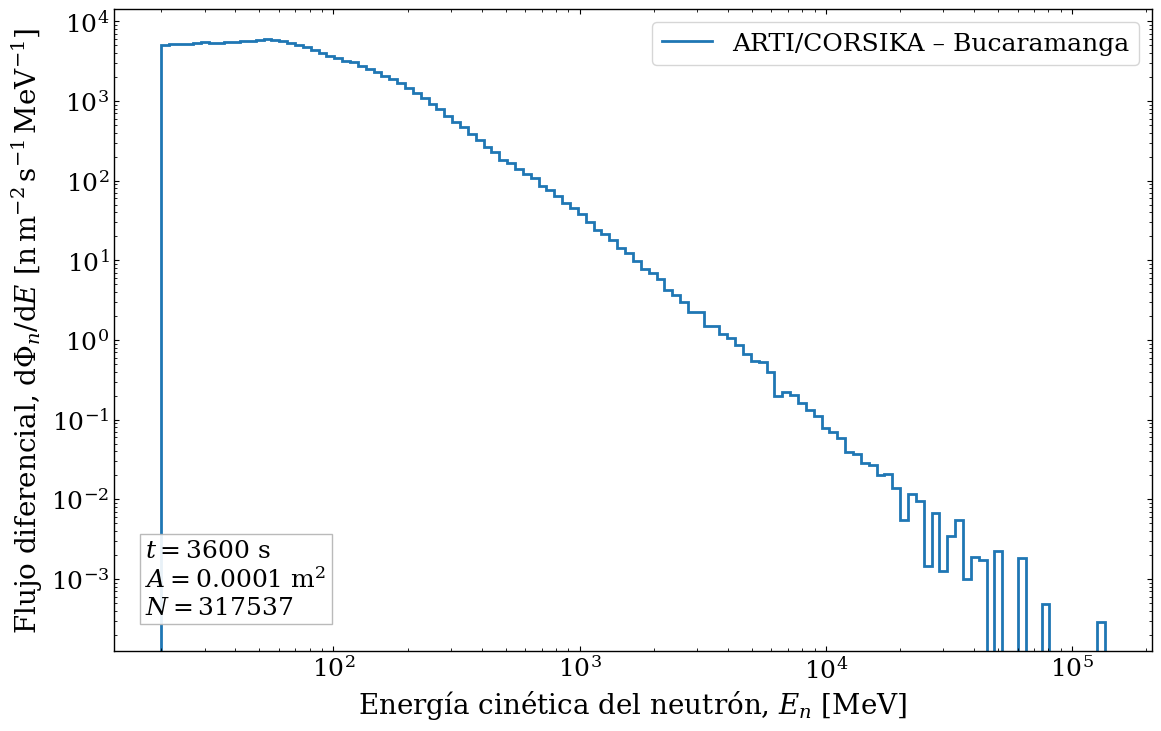

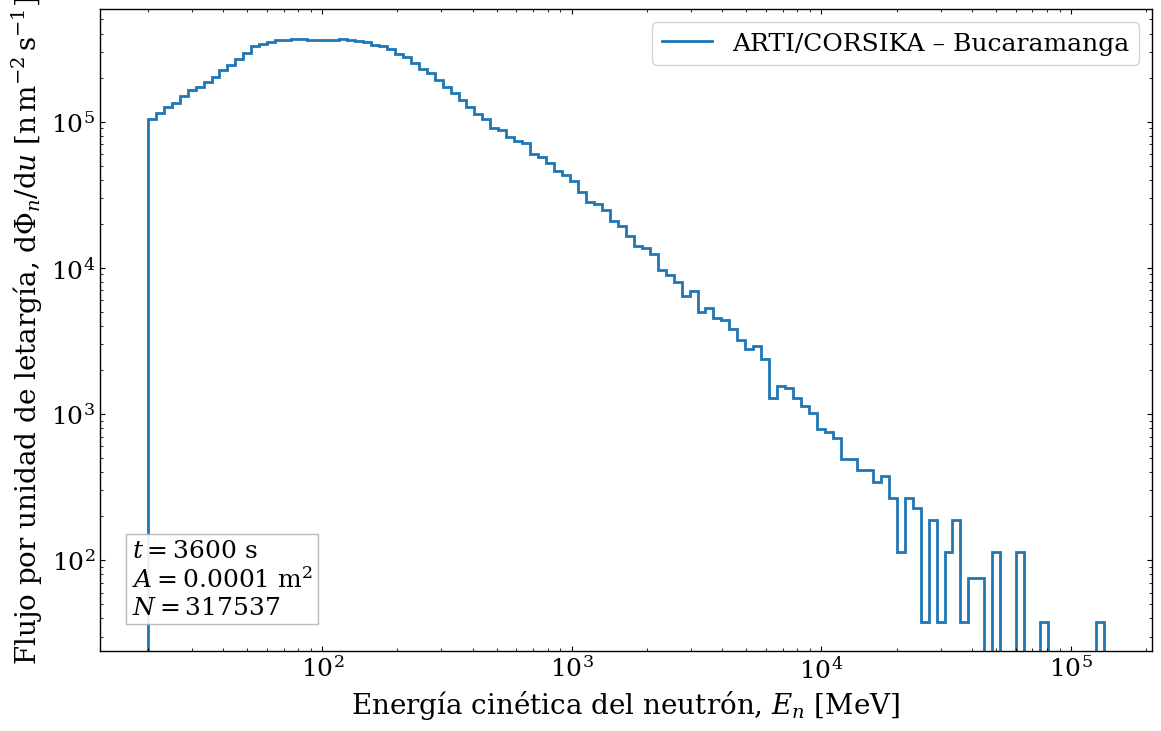

,Parámetro,Valor
0,Número total de neutrones,3.175370e+05
1,Tiempo de exposición [s],3.600000e+03
2,Área asumida [m²],1.000000e-04
3,Fluencia [n m⁻²],3.175370e+09
4,Flujo integrado promedio [n m⁻² s⁻¹],8.820472e+05
5,Energía mínima [MeV],2.000091e+01
6,Percentil 1 % [MeV],2.173735e+01
7,Percentil 10 % [MeV],3.665009e+01
8,Mediana [MeV],1.094960e+02
9,Percentil 90 % [MeV],4.109983e+02


In [11]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================================
# ARCHIVO Y PARÁMETROS DE NORMALIZACIÓN
# ==========================================================
INPUT_FILE = Path("S3_bga_003600_neutrons.shw")
OUTPUT_DIR = Path("analisis_neutrones_bucaramanga")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPOSURE_TIME_S = 3600.0
AREA_M2 = 1.0e-4
NEUTRON_MASS_GEV = 0.9395654205
N_BINS = 120

COLUMNS = [
    "CorsikaId", "px", "py", "pz", "x", "y", "z",
    "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"
]

# ==========================================================
# LECTURA
# ==========================================================
df = pd.read_csv(
    INPUT_FILE,
    sep=r"\s+",
    header=None,
    names=COLUMNS,
    engine="c"
)

# El archivo suministrado contiene únicamente partículas CORSIKA ID 13.
df = df[df["CorsikaId"] == 13].copy()

# ==========================================================
# MOMENTO Y ENERGÍA CINÉTICA RELATIVISTA
# Se interpreta px, py, pz en GeV/c.
# ==========================================================
p_gev_c = np.sqrt(df["px"]**2 + df["py"]**2 + df["pz"]**2)
ekin_gev = np.sqrt(p_gev_c**2 + NEUTRON_MASS_GEV**2) - NEUTRON_MASS_GEV
ekin_mev = ekin_gev * 1.0e3

valid = np.isfinite(ekin_mev) & (ekin_mev > 0)
ekin_mev = ekin_mev[valid].to_numpy()

# ==========================================================
# BINS LOGARÍTMICOS
# ==========================================================
e_min = float(np.min(ekin_mev))
e_max = float(np.max(ekin_mev))

edges = np.logspace(np.log10(e_min), np.log10(e_max), N_BINS + 1)
centers = np.sqrt(edges[:-1] * edges[1:])
delta_e = np.diff(edges)
delta_u = np.log(edges[1:] / edges[:-1])

counts, _ = np.histogram(ekin_mev, bins=edges)

# ==========================================================
# FLUJOS
# ==========================================================
dphi_dE = counts / (AREA_M2 * EXPOSURE_TIME_S * delta_e)
sigma_dphi_dE = np.sqrt(counts) / (AREA_M2 * EXPOSURE_TIME_S * delta_e)

dphi_du = counts / (AREA_M2 * EXPOSURE_TIME_S * delta_u)
sigma_dphi_du = np.sqrt(counts) / (AREA_M2 * EXPOSURE_TIME_S * delta_u)

fluence_n_m2 = len(ekin_mev) / AREA_M2
integrated_flux_n_m2_s = len(ekin_mev) / (AREA_M2 * EXPOSURE_TIME_S)

# ==========================================================
# TABLA NUMÉRICA
# ==========================================================
spectrum = pd.DataFrame({
    "E_min_MeV": edges[:-1],
    "E_max_MeV": edges[1:],
    "E_center_MeV": centers,
    "Delta_E_MeV": delta_e,
    "Delta_u": delta_u,
    "counts": counts,
    "dPhi_dE_n_m2_s_MeV": dphi_dE,
    "sigma_dPhi_dE": sigma_dphi_dE,
    "dPhi_du_n_m2_s": dphi_du,
    "sigma_dPhi_du": sigma_dphi_du,
})
csv_path = OUTPUT_DIR / "espectros_neutrones_bucaramanga.csv"
spectrum.to_csv(csv_path, index=False)

# ==========================================================
# RESUMEN
# ==========================================================
quantiles = np.quantile(ekin_mev, [0.01, 0.10, 0.50, 0.90, 0.99])

summary = pd.DataFrame({
    "Parámetro": [
        "Número total de neutrones",
        "Tiempo de exposición [s]",
        "Área asumida [m²]",
        "Fluencia [n m⁻²]",
        "Flujo integrado promedio [n m⁻² s⁻¹]",
        "Energía mínima [MeV]",
        "Percentil 1 % [MeV]",
        "Percentil 10 % [MeV]",
        "Mediana [MeV]",
        "Percentil 90 % [MeV]",
        "Percentil 99 % [MeV]",
        "Energía máxima [MeV]",
        "Número de cascadas únicas",
    ],
    "Valor": [
        len(ekin_mev),
        EXPOSURE_TIME_S,
        AREA_M2,
        fluence_n_m2,
        integrated_flux_n_m2_s,
        e_min,
        quantiles[0],
        quantiles[1],
        quantiles[2],
        quantiles[3],
        quantiles[4],
        e_max,
        int(df["shower_id"].nunique()),
    ]
})
summary_path = OUTPUT_DIR / "resumen_neutrones_bucaramanga.csv"
summary.to_csv(summary_path, index=False)

# ==========================================================
# ESTILO
# ==========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def format_axes(ax):
    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.30)
    #ax.grid(True, which="minor", linestyle=":", linewidth=0.35, alpha=0.12)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

# ==========================================================
# FIGURA 1: FLUJO DIFERENCIAL
# ==========================================================
fig1, ax1 = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
ax1.stairs(dphi_dE, edges, linewidth=2.0, label="ARTI/CORSIKA – Bucaramanga")
ax1.set_xlabel(r"Energía cinética del neutrón, $E_n$ [MeV]")
ax1.set_ylabel(
    r"Flujo diferencial, $\mathrm{d}\Phi_n/\mathrm{d}E$ "
    r"[$\mathrm{n\,m^{-2}\,s^{-1}\,MeV^{-1}}$]"
)
format_axes(ax1)
ax1.legend(loc="upper right", frameon=True)
ax1.text(
    0.03, 0.05,
    f"$t={EXPOSURE_TIME_S:.0f}$ s\n"
    f"$A={AREA_M2:.4f}$ m$^2$\n"
    f"$N={len(ekin_mev):}$",
    transform=ax1.transAxes,
    va="bottom",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9)
)
diff_pdf = OUTPUT_DIR / "flujo_diferencial_neutrones_bucaramanga.pdf"
diff_png = OUTPUT_DIR / "flujo_diferencial_neutrones_bucaramanga.png"
fig1.savefig(diff_pdf, bbox_inches="tight")
fig1.savefig(diff_png, dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig1)

# ==========================================================
# FIGURA 2: FLUJO POR UNIDAD DE LETARGÍA
# ==========================================================
fig2, ax2 = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
ax2.stairs(dphi_du, edges, linewidth=2.0, label="ARTI/CORSIKA – Bucaramanga")
ax2.set_xlabel(r"Energía cinética del neutrón, $E_n$ [MeV]")
ax2.set_ylabel(
    r"Flujo por unidad de letargía, $\mathrm{d}\Phi_n/\mathrm{d}u$ "
    r"[$\mathrm{n\,m^{-2}\,s^{-1}}$]"
)
format_axes(ax2)
ax2.legend(loc="upper right", frameon=True)
ax2.text(
    0.03, 0.05,
    f"$t={EXPOSURE_TIME_S:.0f}$ s\n"
    f"$A={AREA_M2:.4f}$ m$^2$\n"
    f"$N={len(ekin_mev):}$",
    transform=ax2.transAxes,
    va="bottom",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9)
)
leth_pdf = OUTPUT_DIR / "flujo_letargico_neutrones_bucaramanga.pdf"
leth_png = OUTPUT_DIR / "flujo_letargico_neutrones_bucaramanga.png"
fig2.savefig(leth_pdf, bbox_inches="tight")
fig2.savefig(leth_png, dpi=600, bbox_inches="tight")
plt.show()
plt.close(fig2)

# ==========================================================
# CÓDIGO REPRODUCIBLE
# ==========================================================
script_path = OUTPUT_DIR / "generar_espectros_neutrones_bucaramanga.py"
script_text = r'''import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

INPUT_FILE = Path("S3_bga_003600_neutrons.shw")
OUTPUT_DIR = Path("analisis_neutrones_bucaramanga")
OUTPUT_DIR.mkdir(exist_ok=True)

EXPOSURE_TIME_S = 3600.0
AREA_M2 = 1.0
NEUTRON_MASS_GEV = 0.9395654205
N_BINS = 120

COLUMNS = [
    "CorsikaId", "px", "py", "pz", "x", "y", "z",
    "shower_id", "prm_id", "prm_energy", "prm_theta", "prm_phi"
]

df = pd.read_csv(INPUT_FILE, sep=r"\s+", header=None, names=COLUMNS)
df = df[df["CorsikaId"] == 13].copy()

p_gev_c = np.sqrt(df["px"]**2 + df["py"]**2 + df["pz"]**2)
ekin_mev = (
    np.sqrt(p_gev_c**2 + NEUTRON_MASS_GEV**2)
    - NEUTRON_MASS_GEV
) * 1.0e3
ekin_mev = ekin_mev[np.isfinite(ekin_mev) & (ekin_mev > 0)].to_numpy()

edges = np.logspace(
    np.log10(ekin_mev.min()),
    np.log10(ekin_mev.max()),
    N_BINS + 1
)
centers = np.sqrt(edges[:-1] * edges[1:])
delta_e = np.diff(edges)
delta_u = np.log(edges[1:] / edges[:-1])
counts, _ = np.histogram(ekin_mev, bins=edges)

dphi_dE = counts / (AREA_M2 * EXPOSURE_TIME_S * delta_e)
dphi_du = counts / (AREA_M2 * EXPOSURE_TIME_S * delta_u)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 15,
    "axes.labelsize": 19,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def format_axes(ax):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.30)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.35, alpha=0.12)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())

fig, ax = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
ax.stairs(dphi_dE, edges, linewidth=2.0, label="ARTI/CORSIKA – Bucaramanga")
ax.set_xlabel(r"Energía cinética del neutrón, $E_n$ [MeV]")
ax.set_ylabel(
    r"Flujo diferencial, $\mathrm{d}\Phi_n/\mathrm{d}E$ "
    r"[$\mathrm{n\,m^{-2}\,s^{-1}\,MeV^{-1}}$]"
)
format_axes(ax)
ax.legend()
fig.savefig(OUTPUT_DIR / "flujo_diferencial_neutrones_bucaramanga.pdf",
            bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "flujo_diferencial_neutrones_bucaramanga.png",
            dpi=600, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
ax.stairs(dphi_du, edges, linewidth=2.0, label="ARTI/CORSIKA – Bucaramanga")
ax.set_xlabel(r"Energía cinética del neutrón, $E_n$ [MeV]")
ax.set_ylabel(
    r"Flujo por unidad de letargía, $\mathrm{d}\Phi_n/\mathrm{d}u$ "
    r"[$\mathrm{n\,m^{-2}\,s^{-1}}$]"
)
format_axes(ax)
ax.legend()
fig.savefig(OUTPUT_DIR / "flujo_letargico_neutrones_bucaramanga.pdf",
            bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "flujo_letargico_neutrones_bucaramanga.png",
            dpi=600, bbox_inches="tight")
plt.close(fig)

pd.DataFrame({
    "E_min_MeV": edges[:-1],
    "E_max_MeV": edges[1:],
    "E_center_MeV": centers,
    "counts": counts,
    "dPhi_dE_n_m2_s_MeV": dphi_dE,
    "dPhi_du_n_m2_s": dphi_du,
}).to_csv(OUTPUT_DIR / "espectros_neutrones_bucaramanga.csv", index=False)

print(f"N = {len(ekin_mev):,}")
print(f"Fluencia = {len(ekin_mev)/AREA_M2:.6e} n/m²")
print(
    "Flujo integrado promedio = "
    f"{len(ekin_mev)/(AREA_M2*EXPOSURE_TIME_S):.6e} n/(m² s)"
)
'''
script_path.write_text(script_text, encoding="utf-8")

summary


Datos guardados en Neutrones-30sg-Bga.txt:
    CorsikaId  px  py   momento  x  y  z  shower_id  prm_id  prm_energy  \
0         13   0   0  0.944610  0  0  0          0       0           0   
1         13   0   0  0.360095  0  0  0          0       0           0   
2         13   0   0  0.830201  0  0  0          0       0           0   
3         13   0   0  0.974311  0  0  0          0       0           0   
4         13   0   0  0.539631  0  0  0          0       0           0   

   prm_theta  prm_phi  
0          0        0  
1          0        0  
2          0        0  
3          0        0  
4          0        0  


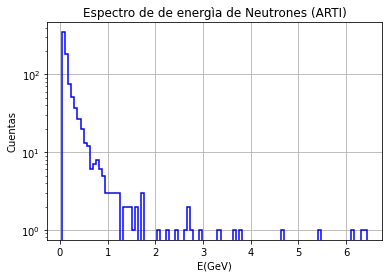

In [8]:
import pandas as pd
Masa_neutron=0.939565
# Lee el archivo de texto
nombre_archivo_entrada = 'Flujo_30sg_neutrones.txt'
datos = pd.read_csv(nombre_archivo_entrada, sep='\t')

# Modifica algunos valores
datos['px'] = 0
datos['py'] = 0
datos['x'] = 0
datos['y'] = 0
datos['z'] = 0
datos['shower_id'] = 0
datos['prm_id'] = 0
datos['prm_energy'] = 0
datos['prm_theta'] = 0
datos['prm_phi'] = 0

E_cinetica=datos['E_cinetica'] = (datos['momento']**2 + Masa_neutron**2)**0.5 - Masa_neutron 
# Selecciona las columnas deseadas
columnas_seleccionadas = ['CorsikaId', 'px', 'py', 'momento', 'x', 'y', 'z', 'shower_id', 'prm_id', 'prm_energy', 'prm_theta', 'prm_phi']
num_cifras_significativas = 5

nombre_archivo_salida = 'Neutrones-30sg-Bga.txt'
#datos[columnas_seleccionadas].to_csv(nombre_archivo_salida, sep='\t', index=False, float_format=f'%.{num_cifras_significativas}g')
datos[columnas_seleccionadas].to_csv(nombre_archivo_salida, sep='\t', index=False, float_format=f'%.{num_cifras_significativas}g', header=False)


# Visualiza los primeros registros de los datos guardados
print(f'Datos guardados en {nombre_archivo_salida}:\n', datos[columnas_seleccionadas].head())
plt.hist(E_cinetica, bins=100,histtype='step', lw=1.5,edgecolor='blue', log=True)
plt.title('Espectro de de energìa de Neutrones (ARTI)')
plt.xlabel('E(GeV)')
plt.ylabel('Cuentas')
plt.grid(True)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
# Aumentar el tamaño de las etiquetas de los ejes
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
pdf_filename_stat_charge = 'Energia-neutrones_Arti-30sg.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Energia_neutrones_Arti-30sg.jpg', format='jpg')
plt.show()




In [10]:
file_path = 'salida_bga_30.shw'  # Reemplaza con la ruta real de tu archivo
new_data_list = []
with open(file_path, 'r') as file:
    for line in file:
        fields = line.strip().split()
        # Verifica que haya al menos 7 valores en la línea
        if len(fields) == 12:
            particle_type, px, py, pz, x, y, z, shower_id, prm_id, prm_energy, prm_theta, prm_phi = fields
            px = float(px) * 0.001
            py = float(py) * 0.001
            pz = float(pz) * 0.001
            # Resto del código...
        else:
            print(f"Advertencia: Ignorando línea con un número incorrecto de valores: {line}")
    
        new_line = f"{13} {px} {py} {pz} {x} {y} {z} 0 0 0 0 0"
        new_data_list.append(new_line)    

In [5]:
# Escribir los datos en un nuevo archivo con el nuevo formato
with open('bga_neutron.dat', 'w') as new_file:
    # Agregar la línea de cabecera al inicio del archivo
    new_file.write('#CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi\n')
    new_file.write('\n'.join(new_data_list))

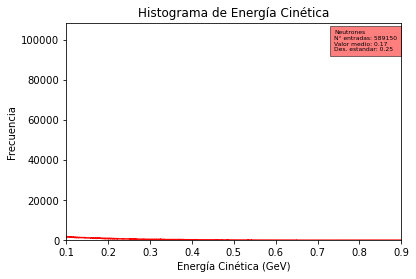

Se ha creado el nuevo archivo: neutron_jessica.txt
              px        py        pz   momento  E_cinetica
0       0.026573  0.002257 -0.018092  0.032226    0.000553
1       0.013667  0.021571 -0.019107  0.031893    0.000541
2      -0.114001 -0.167546 -0.268368  0.336287    0.058369
3      -0.024456  0.001801 -0.078038  0.081800    0.003554
4       0.064220 -0.014282 -0.033203  0.073693    0.002886
...          ...       ...       ...       ...         ...
589145  0.275933 -0.235332 -0.599134  0.700344    0.232299
589146 -0.138434  0.219184 -0.125954  0.288219    0.043213
589147  0.132740  0.314647 -0.549151  0.646676    0.201037
589148 -0.157530  0.187125 -0.500833  0.557373    0.152885
589149 -0.141919 -0.301884 -0.926585  0.984802    0.421544

[589150 rows x 5 columns]


In [6]:
import pandas as pd
Masa_neutron=0.939565
# Reemplaza 'tu_archivo.txt' con la ruta real de tu archivo
archivo = 'bga_neutron.dat'

# Leer el archivo con pandas
datos = pd.read_csv(archivo, sep=' ')

# Realizar operaciones entre columnas
datos['momento'] = (datos['px']**2 + datos['py']**2 + datos['pz']**2)**0.5
datos['E_cinetica'] = (datos['momento']**2 + Masa_neutron**2)**0.5 - Masa_neutron 

columnas_seleccionadas = ['px', 'py', 'pz', 'momento', 'E_cinetica']
nuevos_datos = datos[columnas_seleccionadas]

energia_cinetica = datos['E_cinetica']
num_bins = int(math.sqrt(len(energia_cinetica)))

# Crear el histograma con escala logarítmica en el eje Y
plt.hist(energia_cinetica, bins=num_bins,histtype='step', lw=1.5,edgecolor='red', log=False)
# Agregar un recuadro con información
num_entries = len(energia_cinetica)
mean = sum(energia_cinetica) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in energia_cinetica) / num_entries)

info_text = f'Neutrones\nN° entradas: {num_entries}\nValor medio: {mean:.2f}\nDes. estandar: {std_dev:.2f}'
plt.text(0.80, 0.87, info_text, fontsize=6, transform=plt.gca().transAxes, bbox=dict(facecolor='red', alpha=0.5))
plt.xlim(0.1, 0.9)
#pdf_filename_stat_charge = 'Histograma_Carga_Total_Agua_NaCl.pdf'
#plt.savefig(pdf_filename_stat_charge, format='pdf')
#plt.show()

# Generar un histograma
#plt.hist(energia_cinetica, bins=30, color='blue', edgecolor='black')
plt.title('Histograma de Energía Cinética')
plt.xlabel('Energía Cinética (GeV)')
plt.ylabel('Frecuencia')
plt.show()

# Reemplaza 'nuevo_archivo.txt' con el nombre que desees para el nuevo archivo
archivo_salida = 'neutron_jessica.txt'

nuevos_datos.to_csv(archivo_salida, sep='\t', index=False, float_format='%.5f')  # Puedes cambiar '\t' al delimitador que desees

print(f'Se ha creado el nuevo archivo: {archivo_salida}')


# Mostrar el resultado
print(nuevos_datos)

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Reemplaza 'tu_archivo.csv' con la ruta real de tu archivo
archivo = 'neutron_jessica.txt'

# Leer el archivo CSV con pandas
datos = pd.read_csv(archivo)

# Seleccionar la columna 'E_cinetica'
energia_cinetica = datos['E_cinetica']

# Generar un histograma
plt.hist(energia_cinetica, bins=30, color='blue', edgecolor='black')
plt.title('Histograma de Energía Cinética')
plt.xlabel('Energía Cinética')
plt.ylabel('Frecuencia')
plt.show()

KeyError: 'E_cinetica'

In [4]:


file_path = 'bga_neutron.dat'
neutron_data = pd.read_csv(file_path, sep='\t')
Masa_neutron=0.939565
#neutron_data = neutron_data.iloc[:, 1:]
selected_columns = ['px', 'py', 'pz','x', 'y', 'z']
print(neutron_data)
#print(neutron_data.columns)
#print(neutron_data.head())
# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
#neutron_data['MOMENTO'] = ((neutron_data['px']**2 + neutron_data['py']**2 + neutron_data['pz']**2)**0.5)
# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
#neutron_data['E_cinetica'] = (neutron_data['MOMENTO']**2 + Masa_neutron**2)**0.5-Masa_neutron

       #CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi
0       13 0.0265729 0.0022570199999999998 -0.018092 4...                     
1       13 0.013666600000000001 0.0215714 -0.0191068 6...                     
2       13 -0.114001 -0.167546 -0.268368 89536.6 -7508...                     
3       13 -0.0244558 0.00180108 -0.078038 620050 -562...                     
4       13 0.06422 -0.0142816 -0.0332029 224260 -71803...                     
...                                                   ...                     
589145  13 0.275933 -0.23533199999999999 -0.599134 624...                     
589146  13 -0.138434 0.219184 -0.12595399999999998 -41...                     
589147  13 0.13274000000000002 0.314647 -0.549151 -241...                     
589148  13 -0.15753 0.187125 -0.5008330000000001 -9241...                     
589149  13 -0.14191900000000002 -0.30188400000000004 -...                     

[589150 rows x 1 columns]


In [47]:
import pandas as pd
# Lee el archivo
file_path = 'bga_neutron_3600.dat'
neutron_data = pd.read_csv(file_path, sep='\t')
Masa_neutron=0.939565
new_data_list = []

with open(archivo_datos, 'r') as file:
    for line in file:
        fields = line.strip().split()
        particle_type, x, y, z, px, py, pz = fields
        px = float(px) * 0.001
        py = float(py) * 0.001
        pz = float(pz) * 0.001
        # Asegurarnos de que pz sea positivo
        #pz = abs(float(pz))
        # Crear una nueva línea con la estructura modificada
        new_line = f"{13} {px} {py} {pz} {x} {y} {z} 0 0 0 0 0"
        new_data_list.append(new_line)
        
        #new_file_path = os.path.splitext(file_path)[0] + '.shw'

# Escribir los datos en un nuevo archivo con el nuevo formato
with open('bga_neutron.dat', 'w') as new_file:
    # Agregar la línea de cabecera al inicio del archivo
    new_file.write('#CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi\n')
    new_file.write('\n'.join(new_data_list))

ValueError: too many values to unpack (expected 7)

In [5]:
import pandas as pd
file_path = 'bga_neutron.dat'
neutron_data = pd.read_csv(file_path, sep='\t')
Masa_neutron=0.939565
#neutron_data = neutron_data.iloc[:, 1:]
selected_columns = ['px', 'py', 'pz','x', 'y', 'z']
print(neutron_data)
#print(neutron_data.columns)
#print(neutron_data.head())
# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
neutron_data['MOMENTO'] = ((neutron_data['px']**2 + neutron_data['py']**2 + neutron_data['pz']**2)**0.5)
# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
#neutron_data['E_cinetica'] = (neutron_data['MOMENTO']**2 + Masa_neutron**2)**0.5-Masa_neutron


       #CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi
0       13 0.0265729 0.0022570199999999998 -0.018092 4...                     
1       13 0.013666600000000001 0.0215714 -0.0191068 6...                     
2       13 -0.114001 -0.167546 -0.268368 89536.6 -7508...                     
3       13 -0.0244558 0.00180108 -0.078038 620050 -562...                     
4       13 0.06422 -0.0142816 -0.0332029 224260 -71803...                     
...                                                   ...                     
589145  13 0.275933 -0.23533199999999999 -0.599134 624...                     
589146  13 -0.138434 0.219184 -0.12595399999999998 -41...                     
589147  13 0.13274000000000002 0.314647 -0.549151 -241...                     
589148  13 -0.15753 0.187125 -0.5008330000000001 -9241...                     
589149  13 -0.14191900000000002 -0.30188400000000004 -...                     

[589150 rows x 1 columns]


KeyError: 'px'

In [24]:
with open(archivo_datos, 'r') as file:
    for line in file:
        fields = line.strip().split()
        particle_type, x, y, z, px, py, pz = fields
        # Asegurarnos de que pz sea positivo
        pz = abs(float(pz))
        # Crear una nueva línea con la estructura modificada
        new_line = f"{13} {px} {py} {pz} {x} {y} {z} 0 0 0 0 0"
        new_data_list.append(new_line)

In [25]:
#new_file_path = os.path.splitext(file_path)[0] + '.shw'

# Escribir los datos en un nuevo archivo con el nuevo formato
with open('bga_neutron.dat', 'w') as new_file:
    # Agregar la línea de cabecera al inicio del archivo
    new_file.write('#CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi\n')
    new_file.write('\n'.join(new_data_list))


In [4]:
import pandas as pd
file_path = 'bga_neutron.dat'
neutron_data = pd.read_csv(file_path, sep='\t')
Masa_neutron=0.939565
# Selecciona las columnas de interés
# Elimina la primera columna ('id')
print(neutron_data)


#neutron_data = neutron_data.iloc[:, 1:]
#selected_columns = ['px', 'py', 'pz','x', 'y', 'z']

# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
#neutron_data['MOMENTO'] = ((neutron_data['px']**2 + neutron_data['py']**2 + neutron_data['pz']**2)**0.5)
# Calcula la raíz cuadrada de la suma de los cuadrados de PX, PY y PZ
#neutron_data['E_cinetica'] = (neutron_data['MOMENTO']**2 + Masa_neutron**2)**0.5-Masa_neutron


       #CorsikaID px py pz x y z shower_id prm_id prm_energy prm_theta prm_phi
0       13 0.0265729 0.0022570199999999998 -0.018092 4...                     
1       13 0.013666600000000001 0.0215714 -0.0191068 6...                     
2       13 -0.114001 -0.167546 -0.268368 89536.6 -7508...                     
3       13 -0.0244558 0.00180108 -0.078038 620050 -562...                     
4       13 0.06422 -0.0142816 -0.0332029 224260 -71803...                     
...                                                   ...                     
589145  13 0.275933 -0.23533199999999999 -0.599134 624...                     
589146  13 -0.138434 0.219184 -0.12595399999999998 -41...                     
589147  13 0.13274000000000002 0.314647 -0.549151 -241...                     
589148  13 -0.15753 0.187125 -0.5008330000000001 -9241...                     
589149  13 -0.14191900000000002 -0.30188400000000004 -...                     

[589150 rows x 1 columns]


In [ ]:
# Realizar operaciones entre columnas
datos['momento'] = (datos['px']**2 + datos['py']**2 + datos['pz']**2)**0.5
datos['E_cinetica'] = (datos['momento']**2 + Masa_neutron**2)**0.5 - Masa_neutron 
# Muestra los primeros cinco registros para verificar si se ha leído correctamente
print(datos.head())

columnas_seleccionadas = ['px', 'py', 'pz', 'momento', 'E_cinetica']
nuevos_datos = datos[columnas_seleccionadas]

energia_cinetica = nuevos_datos['E_cinetica']
#momento_neutron = nuevos_datos['momento']
momento_neutron = nuevos_datos['log_momento'] = np.log(nuevos_datos['momento'])

#nuevos_datos['log_momento'] = np.log(nuevos_datos['momento'])
plt.figure(figsize=(12, 8))
#plt.hist(energia_cinetica, bins=100,histtype='step', lw=1.5,edgecolor='red', log=True)
plt.hist(momento_neutron, bins=840,histtype='step', lw=1.5,edgecolor='red', log=True)
# Agregar un recuadro con información
#num_entries = len(energia_cinetica)
#mean = sum(energia_cinetica) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in energia_cinetica) / num_entries)

#info_text = f'Neutrones\nN° entradas: {num_entries}\nValor medio: {mean:.2f}\nDes. estandar: {std_dev:.2f}'
#plt.text(0.80, 0.87, info_text, fontsize=6, transform=plt.gca().transAxes, bbox=dict(facecolor='red', alpha=0.5))
#plt.xlim(0.1, 0.9)
#pdf_filename_stat_charge = 'Histograma_Carga_Total_Agua_NaCl.pdf'
#plt.savefig(pdf_filename_stat_charge, format='pdf')
#plt.show()

# Generar un histograma
#plt.hist(energia_cinetica, bins=30, color='blue', edgecolor='black')
plt.title('Histograma de Energía Cinética')
plt.xlabel('Energía Cinética (GeV)')
plt.ylabel('Frecuencia')
plt.show()
